# Курсовая работа

## Сравнительный анализ методов векторизации текста для задачи классификации отзывов



# Импорт библиотек

In [ ]:
import re
import random
import warnings
import copy

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import time
import sys

from datasets import load_dataset
from sklearn.model_selection import train_test_split

from scipy import sparse
from itertools import product

from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.naive_bayes import MultinomialNB, GaussianNB

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

warnings.filterwarnings("ignore")

RANDOM_STATE = 42
random.seed(RANDOM_STATE)
np.random.seed(RANDOM_STATE)

pd.set_option("display.max_colwidth", 200)

---

## Загрузка датасетов

Загрузка трёх датасетов с отзывами из разных предметных областей:

- **IMDb** — отзывы на фильмы
- **Amazon Polarity** — отзывы на товары
- **Yelp Polarity** — отзывы на сервисы и заведения

Все выбранные датасеты предназначены для решения задачи бинарной классификации.

---

## Загрузка датасета IMDb

Датасет **IMDb** содержит текстовые отзывы на фильмы и используется для задачи бинарной классификации тональности.  
Он включает 100 000 записей:  
- `train` — 25 000 отзывов
- `test` — 25 000 отзывов
- `unsupervised` — 50 000 отзывов без меток
Язык датасета — английский.

Метки в размеченной части принимают два значения: 0 — отрицательный отзыв и 1 — положительный отзыв.

Столбцы в исходном датасете:
- `text` — текст отзыва,
- `label` — метка класса.

В работе используются только обучающая и тестовая части датасета, так как они содержат размеченные отзывы и подходят для дальнейшего обучения и оценки моделей классификации.

In [ ]:
imdb = load_dataset("imdb")

imdb_train = pd.DataFrame(imdb["train"])[["text", "label"]].copy()
imdb_test = pd.DataFrame(imdb["test"])[["text", "label"]].copy()

print("IMDb train shape:", imdb_train.shape)
print("IMDb test shape:", imdb_test.shape)

imdb_train.head(3)

IMDb train shape: (25000, 2)
IMDb test shape: (25000, 2)


,text,label
0,I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if i...,0
1,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim t...",0
2,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touc...,0


---

## Загрузка датасета Amazon Polarity

Датасет Amazon Polarity содержит текстовые отзывы на товары и используется для задачи бинарной классификации тональности.  
Полная версия датасета включает 4 000 000 записей:
- `train` — 3 600 000 отзывов
- `test` — 400 000 отзывов

Язык датасета — английский.

Метки в датасете принимают два значения: 0 и 1, соответствующие двум классам полярности отзывов. Датасет сформирован на основе отзывов Amazon, при этом каждый объект включает заголовок и основной текст отзыва.

Столбцы в исходном датасете:
- `title` — заголовок отзыва
- `content` — основной текст
- `label` — метка класса

В работе используется стратифицированная подвыборка, сформированная из полной версии набора данных. Для экспериментов отобраны 100000 отзывов из обучающей выборки и 20000 отзывов из тестовой выборки с сохранением исходного баланса классов.

Для дальнейшей работы заголовок и основной текст объединяются в один столбец `text`.

In [ ]:
amazon = load_dataset("amazon_polarity")

amazon_train_raw = pd.DataFrame(amazon["train"])[["title", "content", "label"]].copy()
amazon_test_raw = pd.DataFrame(amazon["test"])[["title", "content", "label"]].copy()

amazon_train_raw, _ = train_test_split(
    amazon_train_raw,
    train_size=100000,
    stratify=amazon_train_raw["label"],
    random_state=42
)

amazon_test_raw, _ = train_test_split(
    amazon_test_raw,
    train_size=20000,
    stratify=amazon_test_raw["label"],
    random_state=42
)

amazon_train_raw = amazon_train_raw.reset_index(drop=True)
amazon_test_raw = amazon_test_raw.reset_index(drop=True)

amazon_train = pd.DataFrame({
    "text": (
        amazon_train_raw["title"].fillna("").astype(str).str.strip() + " " +
        amazon_train_raw["content"].fillna("").astype(str).str.strip()
    ).str.strip(),
    "label": amazon_train_raw["label"]
})

amazon_test = pd.DataFrame({
    "text": (
        amazon_test_raw["title"].fillna("").astype(str).str.strip() + " " +
        amazon_test_raw["content"].fillna("").astype(str).str.strip()
    ).str.strip(),
    "label": amazon_test_raw["label"]
})

print("Amazon train shape:", amazon_train.shape)
print("Amazon test shape:", amazon_test.shape)

amazon_train.head(3)

Amazon train shape: (100000, 2)
Amazon test shape: (20000, 2)


,text,label
0,"Poor Connection While you don't need to spend very much on optical cables, this one is really quite poorly made. The connectors are too small and pretty much fall out of my xbox 360 and receiver. ...",0
1,"Words cannot describe how much I love this. When I ordered this, I was just excited to have Last Exile as a part of my DVD collection. Do some research and you'll find out that this series contain...",1
2,"Dryer Balls VS. Fabric Softener and Dryer Sheets Why are these better than dryer sheets and fabric softener? Because dryer sheets and fabric softener are evil. If you're allergic or sensitive, the...",1


In [ ]:
yelp = load_dataset("yelp_polarity")

yelp_train = pd.DataFrame(yelp["train"])[["text", "label"]].copy()
yelp_test = pd.DataFrame(yelp["test"])[["text", "label"]].copy()

print("Yelp train shape:", yelp_train.shape)
print("Yelp test shape:", yelp_test.shape)

yelp_train.head(3)

Yelp train shape: (560000, 2)
Yelp test shape: (38000, 2)


,text,label
0,"Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff. It seems that his staff sim...",0
1,Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because o...,1
2,"I don't know what Dr. Goldberg was like before moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over...",0


---

# Базовая статистика данных

In [ ]:
def dataset_summary(train_df, test_df, dataset_title):
    all_df = pd.concat([train_df, test_df], ignore_index=True)

    return {
        "dataset": dataset_title,
        "train_size": len(train_df),
        "test_size": len(test_df),
        "n_classes": int(all_df["label"].nunique()),
        "avg_text_len_chars": float(all_df["text"].astype(str).str.len().mean()),
        "avg_text_len_words": float(all_df["text"].astype(str).apply(lambda x: len(x.split())).mean()),
    }

In [ ]:
summary_df = pd.DataFrame([
    dataset_summary(imdb_train, imdb_test, "IMDb"),
    dataset_summary(amazon_train, amazon_test, "Amazon Polarity"),
    dataset_summary(yelp_train, yelp_test, "Yelp Polarity")
])

summary_df

,dataset,train_size,test_size,n_classes,avg_text_len_chars,avg_text_len_words
0,IMDb,25000,25000,2,1309.431020,231.156940
1,Amazon Polarity,100000,20000,2,430.423792,78.424558
2,Yelp Polarity,560000,38000,2,726.329321,132.998992


## Анализ данных

На этапе первичного анализа данных необходимо:
- проверить наличие пропусков;
- проверить наличие дубликатов;
- проанализировать распределение классов;
- оценить длину текстов.


In [ ]:
def basic_data_checks(df, dataset_title, split_name):
    return {
        "dataset": dataset_title,
        "split": split_name,
        "rows": len(df),
        "missing_text": int(df["text"].isna().sum()),
        "missing_label": int(df["label"].isna().sum()),
        "duplicate_texts": int(df["text"].duplicated().sum())
    }

### Проверка пропусков и дубликатов

In [ ]:
checks_df = pd.DataFrame([
    basic_data_checks(imdb_train, "IMDb", "train"),
    basic_data_checks(imdb_test, "IMDb", "test"),
    basic_data_checks(amazon_train, "Amazon Polarity", "train"),
    basic_data_checks(amazon_test, "Amazon Polarity", "test"),
    basic_data_checks(yelp_train, "Yelp Polarity", "train"),
    basic_data_checks(yelp_test, "Yelp Polarity", "test"),
])

checks_df

,dataset,split,rows,missing_text,missing_label,duplicate_texts
0,IMDb,train,24904,0,0,0
1,IMDb,test,24801,0,0,0
2,Amazon Polarity,train,100000,0,0,0
3,Amazon Polarity,test,20000,0,0,0
4,Yelp Polarity,train,560000,0,0,0
5,Yelp Polarity,test,38000,0,0,0


Во всех датасетах отсутствуют пропуски в текстах и метках классов.

В датасете IMDb обнаружены дубликаты текстов: 96 в обучающей выборке и 199 в тестовой.

In [ ]:
print("До удаления дубликатов:")
print("IMDb train:", imdb_train.shape)
print("IMDb test:", imdb_test.shape)

imdb_train = imdb_train.drop_duplicates(subset=["text"]).reset_index(drop=True)
imdb_test = imdb_test.drop_duplicates(subset=["text"]).reset_index(drop=True)

print("\nПосле удаления дубликатов:")
print("IMDb train:", imdb_train.shape)
print("IMDb test:", imdb_test.shape)

До удаления дубликатов:
IMDb train: (24904, 2)
IMDb test: (24801, 2)

После удаления дубликатов:
IMDb train: (24904, 2)
IMDb test: (24801, 2)


### Распределение классов

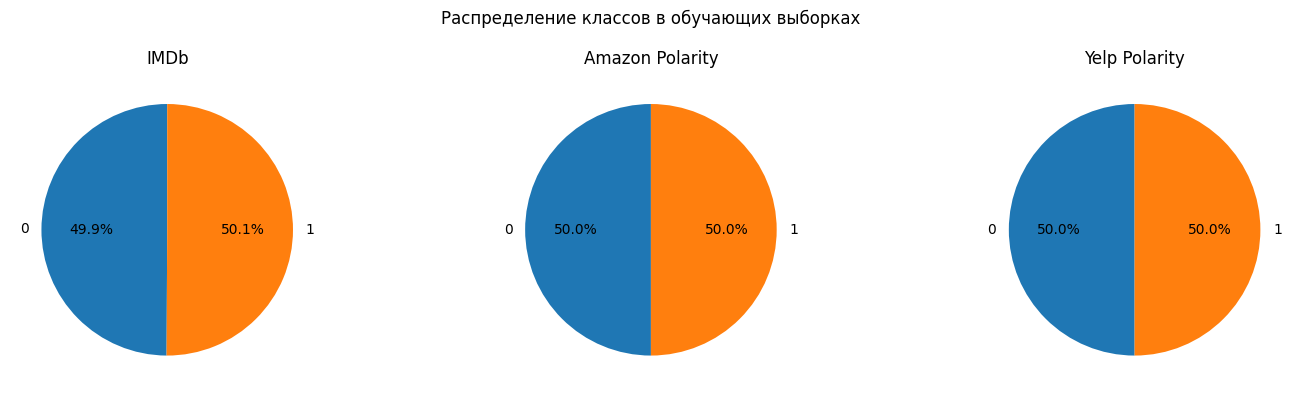

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, (title, df) in zip(
    axes,
    [("IMDb", imdb_train), ("Amazon Polarity", amazon_train), ("Yelp Polarity", yelp_train)]
):
    counts = df["label"].value_counts().sort_index()

    ax.pie(
        counts.values,
        labels=counts.index.astype(str),
        autopct="%1.1f%%",
        startangle=90
    )
    ax.set_title(title)

plt.suptitle("Распределение классов в обучающих выборках")
plt.tight_layout()
plt.show()

Все три датасета сбалансированы, дисбаланса классов нет


### Распределение длины текстов

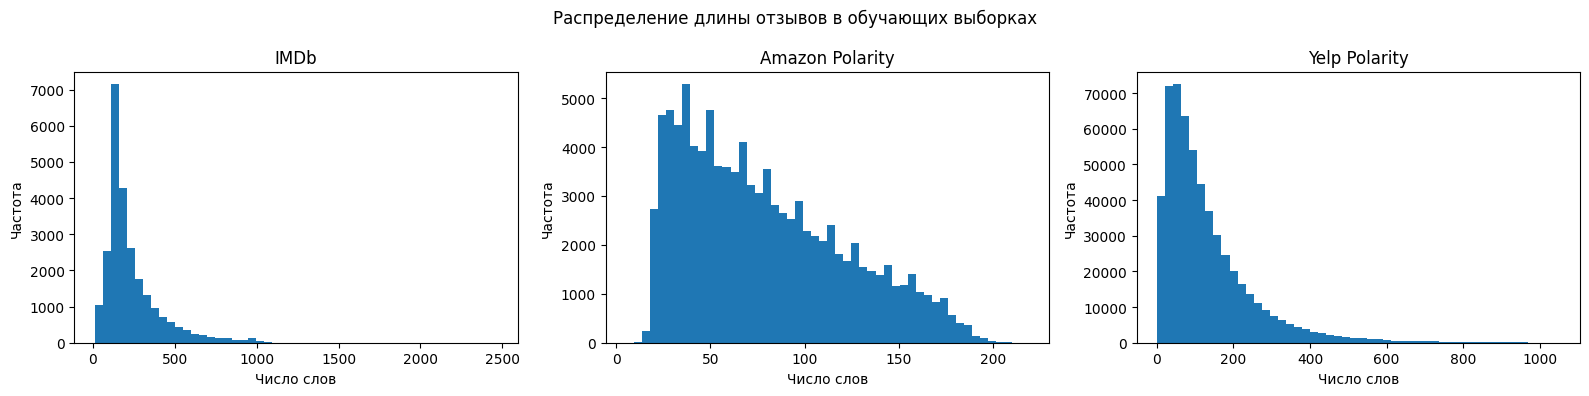

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

for ax, (title, df) in zip(
    axes,
    [("IMDb", imdb_train), ("Amazon Polarity", amazon_train), ("Yelp Polarity", yelp_train)]
):
    lengths = df["text"].astype(str).apply(lambda x: len(x.split()))
    ax.hist(lengths, bins=50)
    ax.set_title(title)
    ax.set_xlabel("Число слов")
    ax.set_ylabel("Частота")

plt.suptitle("Распределение длины отзывов в обучающих выборках")
plt.tight_layout()
plt.show()

### Таблица длины текстов

In [ ]:
def text_length_stats(df, dataset_title):
    lengths_words = df["text"].astype(str).apply(lambda x: len(x.split()))
    lengths_chars = df["text"].astype(str).str.len()

    return {
        "dataset": dataset_title,
        "min_words": int(lengths_words.min()),
        "max_words": int(lengths_words.max()),
        "mean_words": float(lengths_words.mean()),
        "median_words": float(lengths_words.median()),
        "mean_chars": float(lengths_chars.mean())
    }

length_stats_df = pd.DataFrame([
    text_length_stats(imdb_train, "IMDb"),
    text_length_stats(amazon_train, "Amazon Polarity"),
    text_length_stats(yelp_train, "Yelp Polarity")
])

length_stats_df

,dataset,min_words,max_words,mean_words,median_words,mean_chars
0,IMDb,10,2470,234.005702,174.0,1326.376084
1,Amazon Polarity,5,219,78.388740,70.0,430.224020
2,Yelp Polarity,1,1052,133.028873,97.0,726.497923


Датасеты существенно различаются по объёму текстов. Наиболее длинные отзывы содержатся в датасете **IMDb**. В датасете **Yelp Polarity** отзывы имеют среднюю длину. Наиболее короткие тексты представлены в датасете **Amazon Polarity**

---

## Функция очистки текста

- приведение к нижнему регистру
- удаление HTML-тегов
- удаление лишних символов
- удаление лишних пробелов

In [ ]:
html_pattern = re.compile(r"<[^>]+>")
non_word_pattern = re.compile(r"[^a-zA-Z0-9\s']")
multi_space_pattern = re.compile(r"\s+")

def clean_text(text):
    text = str(text)
    text = text.lower()
    text = html_pattern.sub(" ", text)
    text = non_word_pattern.sub(" ", text)
    text = multi_space_pattern.sub(" ", text).strip()
    return text

### Применение предобработки к IMDb

In [ ]:
imdb_train["text_clean"] = imdb_train["text"].apply(clean_text)
imdb_test["text_clean"] = imdb_test["text"].apply(clean_text)

imdb_train[["text", "text_clean"]].head(3)

,text,text_clean
0,I rented I AM CURIOUS-YELLOW from my video store because of all the controversy that surrounded it when it was first released in 1967. I also heard that at first it was seized by U.S. customs if i...,i rented i am curious yellow from my video store because of all the controversy that surrounded it when it was first released in 1967 i also heard that at first it was seized by u s customs if it ...
1,"""I Am Curious: Yellow"" is a risible and pretentious steaming pile. It doesn't matter what one's political views are because this film can hardly be taken seriously on any level. As for the claim t...",i am curious yellow is a risible and pretentious steaming pile it doesn't matter what one's political views are because this film can hardly be taken seriously on any level as for the claim that f...
2,If only to avoid making this type of film in the future. This film is interesting as an experiment but tells no cogent story.<br /><br />One might feel virtuous for sitting thru it because it touc...,if only to avoid making this type of film in the future this film is interesting as an experiment but tells no cogent story one might feel virtuous for sitting thru it because it touches on so man...


### Применение предобработки к Amazon Polarity

In [ ]:
amazon_train["text_clean"] = amazon_train["text"].apply(clean_text)
amazon_test["text_clean"] = amazon_test["text"].apply(clean_text)

amazon_train[["text", "text_clean"]].head(3)

,text,text_clean
0,"Poor Connection While you don't need to spend very much on optical cables, this one is really quite poorly made. The connectors are too small and pretty much fall out of my xbox 360 and receiver. ...",poor connection while you don't need to spend very much on optical cables this one is really quite poorly made the connectors are too small and pretty much fall out of my xbox 360 and receiver thi...
1,"Words cannot describe how much I love this. When I ordered this, I was just excited to have Last Exile as a part of my DVD collection. Do some research and you'll find out that this series contain...",words cannot describe how much i love this when i ordered this i was just excited to have last exile as a part of my dvd collection do some research and you'll find out that this series contains a...
2,"Dryer Balls VS. Fabric Softener and Dryer Sheets Why are these better than dryer sheets and fabric softener? Because dryer sheets and fabric softener are evil. If you're allergic or sensitive, the...",dryer balls vs fabric softener and dryer sheets why are these better than dryer sheets and fabric softener because dryer sheets and fabric softener are evil if you're allergic or sensitive these a...


### Применение предобработки к Yelp Polarity

In [ ]:
yelp_train["text_clean"] = yelp_train["text"].apply(clean_text)
yelp_test["text_clean"] = yelp_test["text"].apply(clean_text)

yelp_train[["text", "text_clean"]].head(3)

,text,text_clean
0,"Unfortunately, the frustration of being Dr. Goldberg's patient is a repeat of the experience I've had with so many other doctors in NYC -- good doctor, terrible staff. It seems that his staff sim...",unfortunately the frustration of being dr goldberg's patient is a repeat of the experience i've had with so many other doctors in nyc good doctor terrible staff it seems that his staff simply neve...
1,Been going to Dr. Goldberg for over 10 years. I think I was one of his 1st patients when he started at MHMG. He's been great over the years and is really all about the big picture. It is because o...,been going to dr goldberg for over 10 years i think i was one of his 1st patients when he started at mhmg he's been great over the years and is really all about the big picture it is because of hi...
2,"I don't know what Dr. Goldberg was like before moving to Arizona, but let me tell you, STAY AWAY from this doctor and this office. I was going to Dr. Johnson before he left and Goldberg took over...",i don't know what dr goldberg was like before moving to arizona but let me tell you stay away from this doctor and this office i was going to dr johnson before he left and goldberg took over when ...


### Проверка пустых текстов после очистки

In [ ]:
empty_after_clean_df = pd.DataFrame([
    {
        "dataset": "IMDb",
        "empty_clean_train": int((imdb_train["text_clean"].str.len() == 0).sum()),
        "empty_clean_test": int((imdb_test["text_clean"].str.len() == 0).sum())
    },
    {
        "dataset": "Amazon Polarity",
        "empty_clean_train": int((amazon_train["text_clean"].str.len() == 0).sum()),
        "empty_clean_test": int((amazon_test["text_clean"].str.len() == 0).sum())
    },
    {
        "dataset": "Yelp Polarity",
        "empty_clean_train": int((yelp_train["text_clean"].str.len() == 0).sum()),
        "empty_clean_test": int((yelp_test["text_clean"].str.len() == 0).sum())
    }
])

empty_after_clean_df

,dataset,empty_clean_train,empty_clean_test
0,IMDb,0,0
1,Amazon Polarity,0,0
2,Yelp Polarity,21,0


### Удаление пустых строк

In [ ]:
imdb_train = imdb_train[imdb_train["text_clean"].str.len() > 0].reset_index(drop=True)
imdb_test = imdb_test[imdb_test["text_clean"].str.len() > 0].reset_index(drop=True)

amazon_train = amazon_train[amazon_train["text_clean"].str.len() > 0].reset_index(drop=True)
amazon_test = amazon_test[amazon_test["text_clean"].str.len() > 0].reset_index(drop=True)

yelp_train = yelp_train[yelp_train["text_clean"].str.len() > 0].reset_index(drop=True)
yelp_test = yelp_test[yelp_test["text_clean"].str.len() > 0].reset_index(drop=True)

In [ ]:
empty_after_clean_df = pd.DataFrame([
    {
        "dataset": "IMDb",
        "empty_clean_train": int((imdb_train["text_clean"].str.len() == 0).sum()),
        "empty_clean_test": int((imdb_test["text_clean"].str.len() == 0).sum())
    },
    {
        "dataset": "Amazon Polarity",
        "empty_clean_train": int((amazon_train["text_clean"].str.len() == 0).sum()),
        "empty_clean_test": int((amazon_test["text_clean"].str.len() == 0).sum())
    },
    {
        "dataset": "Yelp Polarity",
        "empty_clean_train": int((yelp_train["text_clean"].str.len() == 0).sum()),
        "empty_clean_test": int((yelp_test["text_clean"].str.len() == 0).sum())
    }
])

empty_after_clean_df

,dataset,empty_clean_train,empty_clean_test
0,IMDb,0,0
1,Amazon Polarity,0,0
2,Yelp Polarity,0,0


---

## Формирование обучающей, валидационной и тестовой выборок

Для каждого датасета в работе использовалось фиксированное разбиение на обучающую, валидационную и тестовую выборки. Валидационная выборка была введена для выбора модели, контроля качества на промежуточных этапах и снижения риска переобучения. Тестовая выборка использовалась только для итоговой оценки после завершения всех этапов настройки.

В работе применялась стратегия hold-out: данные для каждого датасета разделялись один раз, после чего одно и то же разбиение использовалось во всех последующих экспериментах. Это позволяет корректно сравнивать различные методы векторизации и классификации внутри каждого датасета.

Разбиение выполнялось стратифицированно по классам, чтобы сохранить одинаковое соотношение положительных и отрицательных отзывов в обучающей, валидационной и тестовой выборках.

Для разных датасетов использовались разные объёмы данных. Полный датасет IMDb был оставлен в эксперименте, так как его размер остаётся вычислительно доступным. Для Amazon Polarity использовалась стратифицированная подвыборка, поскольку исходный объём корпуса существенно больше. Yelp Polarity в данной работе использовался в полном объёме. При этом внутри каждого датасета все методы обучались и оценивались на одном и том же фиксированном разбиении, поэтому сравнение выполнялось корректно на уровне каждого корпуса отдельно.

## Построение признаков

На этом этапе будут рассмотрены методы векторизации, позволяющие преобразовать очищенные отзывы в наборы признаков для последующего обучения моделей классификации.

Сначала рассматриваются классические статистические методы:
- **Bag of Words**
- **TF-IDF**

Они являются базовыми и широко применяются в задачах классификации текстов благодаря простоте реализации и высокой эффективности

In [ ]:
VAL_SIZE = 0.2

def make_train_val_split(df, val_size=0.2, random_state=42):
    train_df, val_df = train_test_split(
        df,
        test_size=val_size,
        stratify=df["label"],
        random_state=random_state
    )
    return train_df.reset_index(drop=True), val_df.reset_index(drop=True)

imdb_train, imdb_val = make_train_val_split(
    imdb_train,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE
)

amazon_train, amazon_val = make_train_val_split(
    amazon_train,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE
)

yelp_train, yelp_val = make_train_val_split(
    yelp_train,
    val_size=VAL_SIZE,
    random_state=RANDOM_STATE
)

split_summary_df = pd.DataFrame([
    {
        "dataset": "IMDb",
        "train_shape": imdb_train.shape,
        "val_shape": imdb_val.shape,
        "test_shape": imdb_test.shape
    },
    {
        "dataset": "Amazon Polarity",
        "train_shape": amazon_train.shape,
        "val_shape": amazon_val.shape,
        "test_shape": amazon_test.shape
    },
    {
        "dataset": "Yelp Polarity",
        "train_shape": yelp_train.shape,
        "val_shape": yelp_val.shape,
        "test_shape": yelp_test.shape
    }
])

split_summary_df

,dataset,train_shape,val_shape,test_shape
0,IMDb,"(19923, 3)","(4981, 3)","(24801, 3)"
1,Amazon Polarity,"(80000, 3)","(20000, 3)","(20000, 3)"
2,Yelp Polarity,"(447983, 3)","(111996, 3)","(38000, 3)"


In [ ]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

## Метод Bag of Words

Метод Bag of Words является одним из базовых способов векторизации текстов. Основная идея в представлении каждого документа в виде числового вектора, компоненты которого соответствуют отдельным словам или сочетаниям слов из словаря корпуса. Значение каждой компоненты отражает частоту появления соответствующего токена в тексте.

Пусть корпус состоит из словаря  
$V = \{w_1, w_2, \dots, w_m\}$,  
где $m$ — размер словаря. Тогда каждый документ $d$ представляется вектором

$$
\mathbf{x}^{(d)} = \left(x_1^{(d)}, x_2^{(d)}, \dots, x_m^{(d)}\right),
$$

где $x_i^{(d)}$ — количество вхождений слова $w_i$ в документ $d$.

Таким образом, если слово встречается в документе несколько раз, соответствующее значение вектора увеличивается. Если слово в документе отсутствует, значение равно нулю.

Главной особенностью метода является то, что он не учитывает порядок слов в тексте, а рассматривает документ как неупорядоченный набор токенов. Именно поэтому данный подход получил название «мешок слов».

В работе метод Bag of Words применяется отдельно к каждому датасету.

#### Параметры

Для метода Bag of Words использовались униграммы и биграммы (ngram_range=(1,2)), поскольку в задачах классификации отзывов значимую роль играют не только отдельные слова, но и короткие сочетания слов. Использование биграмм особенно важно для передачи локальной тональности текста. Ограничение max_features=30000 введено для сокращения размерности признакового пространства и уменьшения влияния редких малоинформативных токенов, а min_df=2 позволяет отсечь единичные слова, которые чаще являются шумом. Использование биграмм в задаче классификации отзывов помогает учитывать короткие устойчивые сочетания слов, которые важны для передачи тональности текста.


In [ ]:
def sparse_memory_mb(X):
    memory_bytes = X.data.nbytes + X.indices.nbytes + X.indptr.nbytes
    return memory_bytes / (1024 ** 2)

def total_sparse_memory_mb(*matrices):
    return sum(sparse_memory_mb(X) for X in matrices)

bow_stats = []
MAX_FEATURES = 30000
NGRAM_RANGE = (1, 2)
MIN_DF = 2

print("MAX_FEATURES =", MAX_FEATURES)
print("NGRAM_RANGE =", NGRAM_RANGE)
print("MIN_DF =", MIN_DF)

MAX_FEATURES = 30000
NGRAM_RANGE = (1, 2)
MIN_DF = 2


### Применение к IMDb

In [ ]:
start_time = time.perf_counter()

bow_vectorizer_imdb = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF
)

X_train_bow_imdb = bow_vectorizer_imdb.fit_transform(imdb_train["text_clean"])
X_val_bow_imdb = bow_vectorizer_imdb.transform(imdb_val["text_clean"])
X_test_bow_imdb = bow_vectorizer_imdb.transform(imdb_test["text_clean"])

elapsed_time = time.perf_counter() - start_time
memory_mb = total_sparse_memory_mb(
    X_train_bow_imdb,
    X_val_bow_imdb,
    X_test_bow_imdb
)

bow_stats.append({
    "dataset": "IMDb",
    "method": "Bag of Words",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_bow_imdb.shape,
    "val_shape": X_val_bow_imdb.shape,
    "test_shape": X_test_bow_imdb.shape,
    "vocab_size": len(bow_vectorizer_imdb.vocabulary_)
})

print("IMDb BoW train shape:", X_train_bow_imdb.shape)
print("IMDb BoW val shape:", X_val_bow_imdb.shape)
print("IMDb BoW test shape:", X_test_bow_imdb.shape)
print("Размер словаря IMDb:", len(bow_vectorizer_imdb.vocabulary_))
print("Время построения признаков (train+val+test):", round(elapsed_time, 4), "сек")
print("Память sparse-матриц train+val+test:", round(memory_mb, 2), "MB")

IMDb BoW train shape: (19923, 30000)
IMDb BoW val shape: (4981, 30000)
IMDb BoW test shape: (24801, 30000)
Размер словаря IMDb: 30000
Время построения признаков (train+val+test): 18.1064 сек
Память sparse-матриц train+val+test: 126.14 MB


### Применение к Amazon Polarity

In [ ]:
start_time = time.perf_counter()

bow_vectorizer_amazon = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF
)

X_train_bow_amazon = bow_vectorizer_amazon.fit_transform(amazon_train["text_clean"])
X_val_bow_amazon = bow_vectorizer_amazon.transform(amazon_val["text_clean"])
X_test_bow_amazon = bow_vectorizer_amazon.transform(amazon_test["text_clean"])

elapsed_time = time.perf_counter() - start_time
memory_mb = total_sparse_memory_mb(
    X_train_bow_amazon,
    X_val_bow_amazon,
    X_test_bow_amazon
)

bow_stats.append({
    "dataset": "Amazon Polarity",
    "method": "Bag of Words",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_bow_amazon.shape,
    "val_shape": X_val_bow_amazon.shape,
    "test_shape": X_test_bow_amazon.shape,
    "vocab_size": len(bow_vectorizer_amazon.vocabulary_)
})

print("Amazon BoW train shape:", X_train_bow_amazon.shape)
print("Amazon BoW val shape:", X_val_bow_amazon.shape)
print("Amazon BoW test shape:", X_test_bow_amazon.shape)
print("Размер словаря Amazon:", len(bow_vectorizer_amazon.vocabulary_))
print("Время построения признаков (train+val+test):", round(elapsed_time, 4), "сек")
print("Память sparse-матриц train+val+test:", round(memory_mb, 2), "MB")

Amazon BoW train shape: (80000, 30000)
Amazon BoW val shape: (20000, 30000)
Amazon BoW test shape: (20000, 30000)
Размер словаря Amazon: 30000
Время построения признаков (train+val+test): 18.5529 сек
Память sparse-матриц train+val+test: 119.43 MB


### Применение к Yelp Polarity

In [ ]:
start_time = time.perf_counter()

bow_vectorizer_yelp = CountVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF
)

X_train_bow_yelp = bow_vectorizer_yelp.fit_transform(yelp_train["text_clean"])
X_val_bow_yelp = bow_vectorizer_yelp.transform(yelp_val["text_clean"])
X_test_bow_yelp = bow_vectorizer_yelp.transform(yelp_test["text_clean"])

elapsed_time = time.perf_counter() - start_time
memory_mb = total_sparse_memory_mb(
    X_train_bow_yelp,
    X_val_bow_yelp,
    X_test_bow_yelp
)

bow_stats.append({
    "dataset": "Yelp Polarity",
    "method": "Bag of Words",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_bow_yelp.shape,
    "val_shape": X_val_bow_yelp.shape,
    "test_shape": X_test_bow_yelp.shape,
    "vocab_size": len(bow_vectorizer_yelp.vocabulary_)
})

print("Yelp BoW train shape:", X_train_bow_yelp.shape)
print("Yelp BoW val shape:", X_val_bow_yelp.shape)
print("Yelp BoW test shape:", X_test_bow_yelp.shape)
print("Размер словаря Yelp:", len(bow_vectorizer_yelp.vocabulary_))
print("Время построения признаков (train+val+test):", round(elapsed_time, 4), "сек")
print("Память sparse-матриц train+val+test:", round(memory_mb, 2), "MB")

Yelp BoW train shape: (447983, 30000)
Yelp BoW val shape: (111996, 30000)
Yelp BoW test shape: (38000, 30000)
Размер словаря Yelp: 30000
Время построения признаков (train+val+test): 135.1379 сек
Память sparse-матриц train+val+test: 989.37 MB


In [ ]:
print("Примеры признаков IMDb:")
print(list(bow_vectorizer_imdb.vocabulary_.keys())[:30])

print("\nПримеры признаков Amazon:")
print(list(bow_vectorizer_amazon.vocabulary_.keys())[:30])

print("\nПримеры признаков Yelp:")
print(list(bow_vectorizer_yelp.vocabulary_.keys())[:30])

Примеры признаков IMDb:
['disappointing', 'film', 'performance', 'of', 'actors', 'is', 'weak', 'sets', 'are', 'fine', 'could', 'have', 'been', 'better', 'the', 'story', 'also', 'battle', 'sequences', 'awful', 'sounds', 'and', 'quality', 'trashy', 'history', 'people', 'was', 'told', 'very', 'poorly']

Примеры признаков Amazon:
['not', 'worth', 'the', 'money', 'am', 'stations', 'did', 'work', 'receive', 'on', 'my', 'other', 'fm', 'radio', 'this', 'is', 'piece', 'of', 'junk', 'not worth', 'worth the', 'the money', 'money am', 'did not', 'not work', 'on my', 'my other', 'this is', 'is piece', 'piece of']

Примеры признаков Yelp:
['new', 'york', 'deli', 'best', 'in', 'town', 'after', 'arriving', 'charlotte', 'about', 'eight', 'years', 'ago', 'found', 'what', 'was', 'then', 'restaurant', 'place', 'where', 'jersey', 'could', 'get', 'fix', 'of', 'for', 'me', 'is', 'soul', 'food']


In [ ]:
bow_stats_df = pd.DataFrame(bow_stats)
bow_stats_df

,dataset,method,time_sec,memory_mb,train_shape,val_shape,test_shape,vocab_size
0,IMDb,Bag of Words,18.1064,126.14,"(19923, 30000)","(4981, 30000)","(24801, 30000)",30000
1,Amazon Polarity,Bag of Words,18.5529,119.43,"(80000, 30000)","(20000, 30000)","(20000, 30000)",30000
2,Yelp Polarity,Bag of Words,135.1379,989.37,"(447983, 30000)","(111996, 30000)","(38000, 30000)",30000


### Преимущества и недостатки метода Bag of Words

Преимущества метода:
- простота реализации и внедрения;
- возможность использовать метод как базовое стартовое решение для задачи классификации текстов;
- сравнительно высокая скорость построения признаков;
- хорошая интерпретируемость результатов, так как признаки напрямую связаны со словами и словосочетаниями;
- эффективность в задачах базовой текстовой классификации.

Недостатки метода:
- отсутствие учёта порядка слов и контекста;
- отсутствие информации о семантических связях между словами;
- чувствительность к качеству предобработки текста: если шумовые токены не были удалены, они могут занимать часть признакового пространства и искажать представление текста;
- высокая размерность признакового пространства, особенно на больших корпусах;
- невозможность учитывать смысловые и логические отношения между словами и выражениями.

---

## Метод TF-IDF

Метод TF-IDF является развитием подхода Bag of Words и используется для представления текста в виде числового вектора с учётом важности слов в корпусе. В отличие от обычного подсчёта частот, TF-IDF учитывает не только то, насколько часто слово встречается в конкретном документе, но и то, насколько редко оно встречается во всём наборе текстов.

Вес слова $w$ в документе $d$ вычисляется как произведение двух величин:

$$
\text{TF-IDF}(w, d) = \text{TF}(w, d) \cdot \text{IDF}(w)
$$

где:

$$
\text{TF}(w, d) = \frac{f(w, d)}{\sum_{w' \in d} f(w', d)}
$$

— относительная частота слова $w$ в документе $d$,

$$
\text{IDF}(w) = \log \frac{N}{df(w)}
$$

— обратная частота документа,  
$N$ — число документов в корпусе,  
$df(w)$ — количество документов, в которых встречается слово $w$.

Таким образом, высокий вес получают слова, которые часто встречаются в конкретном документе, но сравнительно редко появляются в других текстах корпуса. Это позволяет уменьшить влияние слишком частых и малоинформативных слов.

Преимущества метода:
- учитывает информативность слов в корпусе;
- снижает влияние слишком частых токенов;
- часто даёт более высокое качество классификации по сравнению с Bag of Words;
- хорошо сочетается с классическими моделями машинного обучения.

Недостатки метода:
- не учитывает порядок слов и контекст;
- не отражает семантическую близость между словами;
- формирует разреженные матрицы высокой размерности.

В данной работе метод TF-IDF применяется отдельно к каждому датасету.

#### Параметры

Для TF-IDF использовались те же базовые параметры, что и для Bag of Words: ngram_range=(1,2), max_features=30000, min_df=2. Это позволяет сохранить сопоставимость между двумя частотными подходами и сравнивать именно способ взвешивания признаков, а не разные словари. Выбор биграмм обусловлен тем, что в текстах отзывов тональность часто выражается локально, через короткие словосочетания, а ограничение размера словаря снижает вычислительную сложность и уменьшает влияние шумовых признаков.

In [ ]:
tfidf_stats = []

### Применение к IMDb

In [ ]:
start_time = time.perf_counter()

tfidf_vectorizer_imdb = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    sublinear_tf=True
)

X_train_tfidf_imdb = tfidf_vectorizer_imdb.fit_transform(imdb_train["text_clean"])
X_val_tfidf_imdb = tfidf_vectorizer_imdb.transform(imdb_val["text_clean"])
X_test_tfidf_imdb = tfidf_vectorizer_imdb.transform(imdb_test["text_clean"])

elapsed_time = time.perf_counter() - start_time
memory_mb = total_sparse_memory_mb(
    X_train_tfidf_imdb,
    X_val_tfidf_imdb,
    X_test_tfidf_imdb
)

tfidf_stats.append({
    "dataset": "IMDb",
    "method": "TF-IDF",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_tfidf_imdb.shape,
    "val_shape": X_val_tfidf_imdb.shape,
    "test_shape": X_test_tfidf_imdb.shape,
    "vocab_size": len(tfidf_vectorizer_imdb.vocabulary_)
})

print("IMDb TF-IDF train shape:", X_train_tfidf_imdb.shape)
print("IMDb TF-IDF val shape:", X_val_tfidf_imdb.shape)
print("IMDb TF-IDF test shape:", X_test_tfidf_imdb.shape)
print("Размер словаря IMDb:", len(tfidf_vectorizer_imdb.vocabulary_))
print("Время построения признаков (train+val+test):", round(elapsed_time, 4), "сек")
print("Память sparse-матриц train+val+test:", round(memory_mb, 2), "MB")

IMDb TF-IDF train shape: (19923, 30000)
IMDb TF-IDF val shape: (4981, 30000)
IMDb TF-IDF test shape: (24801, 30000)
Размер словаря IMDb: 30000
Время построения признаков (train+val+test): 19.3253 сек
Память sparse-матриц train+val+test: 126.14 MB


### Применение к Amazon Polarity

In [ ]:
start_time = time.perf_counter()

tfidf_vectorizer_amazon = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    sublinear_tf=True
)

X_train_tfidf_amazon = tfidf_vectorizer_amazon.fit_transform(amazon_train["text_clean"])
X_val_tfidf_amazon = tfidf_vectorizer_amazon.transform(amazon_val["text_clean"])
X_test_tfidf_amazon = tfidf_vectorizer_amazon.transform(amazon_test["text_clean"])

elapsed_time = time.perf_counter() - start_time
memory_mb = total_sparse_memory_mb(
    X_train_tfidf_amazon,
    X_val_tfidf_amazon,
    X_test_tfidf_amazon
)

tfidf_stats.append({
    "dataset": "Amazon Polarity",
    "method": "TF-IDF",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_tfidf_amazon.shape,
    "val_shape": X_val_tfidf_amazon.shape,
    "test_shape": X_test_tfidf_amazon.shape,
    "vocab_size": len(tfidf_vectorizer_amazon.vocabulary_)
})

print("Amazon TF-IDF train shape:", X_train_tfidf_amazon.shape)
print("Amazon TF-IDF val shape:", X_val_tfidf_amazon.shape)
print("Amazon TF-IDF test shape:", X_test_tfidf_amazon.shape)
print("Размер словаря Amazon:", len(tfidf_vectorizer_amazon.vocabulary_))
print("Время построения признаков (train+val+test):", round(elapsed_time, 4), "сек")
print("Память sparse-матриц train+val+test:", round(memory_mb, 2), "MB")

Amazon TF-IDF train shape: (80000, 30000)
Amazon TF-IDF val shape: (20000, 30000)
Amazon TF-IDF test shape: (20000, 30000)
Размер словаря Amazon: 30000
Время построения признаков (train+val+test): 18.9211 сек
Память sparse-матриц train+val+test: 119.43 MB


### Применение к Yelp Polarity

In [ ]:
start_time = time.perf_counter()

tfidf_vectorizer_yelp = TfidfVectorizer(
    max_features=MAX_FEATURES,
    ngram_range=NGRAM_RANGE,
    min_df=MIN_DF,
    sublinear_tf=True
)

X_train_tfidf_yelp = tfidf_vectorizer_yelp.fit_transform(yelp_train["text_clean"])
X_val_tfidf_yelp = tfidf_vectorizer_yelp.transform(yelp_val["text_clean"])
X_test_tfidf_yelp = tfidf_vectorizer_yelp.transform(yelp_test["text_clean"])

elapsed_time = time.perf_counter() - start_time
memory_mb = total_sparse_memory_mb(
    X_train_tfidf_yelp,
    X_val_tfidf_yelp,
    X_test_tfidf_yelp
)

tfidf_stats.append({
    "dataset": "Yelp Polarity",
    "method": "TF-IDF",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_tfidf_yelp.shape,
    "val_shape": X_val_tfidf_yelp.shape,
    "test_shape": X_test_tfidf_yelp.shape,
    "vocab_size": len(tfidf_vectorizer_yelp.vocabulary_)
})

print("Yelp TF-IDF train shape:", X_train_tfidf_yelp.shape)
print("Yelp TF-IDF val shape:", X_val_tfidf_yelp.shape)
print("Yelp TF-IDF test shape:", X_test_tfidf_yelp.shape)
print("Размер словаря Yelp:", len(tfidf_vectorizer_yelp.vocabulary_))
print("Время построения признаков (train+val+test):", round(elapsed_time, 4), "сек")
print("Память sparse-матриц train+val+test:", round(memory_mb, 2), "MB")

Yelp TF-IDF train shape: (447983, 30000)
Yelp TF-IDF val shape: (111996, 30000)
Yelp TF-IDF test shape: (38000, 30000)
Размер словаря Yelp: 30000
Время построения признаков (train+val+test): 139.0813 сек
Память sparse-матриц train+val+test: 989.37 MB


In [ ]:
tfidf_stats_df = pd.DataFrame(tfidf_stats)
tfidf_stats_df

,dataset,method,time_sec,memory_mb,train_shape,val_shape,test_shape,vocab_size
0,IMDb,TF-IDF,19.3253,126.14,"(19923, 30000)","(4981, 30000)","(24801, 30000)",30000
1,Amazon Polarity,TF-IDF,18.9211,119.43,"(80000, 30000)","(20000, 30000)","(20000, 30000)",30000
2,Yelp Polarity,TF-IDF,139.0813,989.37,"(447983, 30000)","(111996, 30000)","(38000, 30000)",30000


### Преимущества и недостатки метода TF-IDF

Преимущества метода:
- учитывает не только частоту слова в документе, но и его распространённость во всём корпусе;
- менее чувствителен к слишком частым токенам по сравнению с Bag of Words, так как часто встречающиеся слова получают меньший вес;
- позволяет выделять более информативные признаки текста;
- во многих задачах текстовой классификации показывает более высокое качество по сравнению с Bag of Words;
- хорошо сочетается с классическими моделями машинного обучения.

Недостатки метода:
- не учитывает порядок слов и контекст их употребления;
- не формирует полноценного семантического представления текста: слова рассматриваются как отдельные признаки, а не как связанные по смыслу единицы;
- формирует разреженные матрицы высокой размерности;
- по сравнению с Bag of Words требует дополнительного вычисления весов признаков; при этом объём памяти итоговых разреженных матриц может оставаться близким к Bag of Words, поскольку структура хранения признаков у методов во многом совпадает.
- построение и применение признаков обычно требует большего времени по сравнению с Bag of Words.

---

## Нейросетевые подходы

## Метод Word2Vec

Метод Word2Vec относится к нейросетевым подходам к векторизации текста и используется для построения плотных векторных представлений слов. В отличие от частотных методов, Word2Vec позволяет учитывать статистическую близость слов в корпусе: слова, употребляющиеся в похожих контекстах, получают близкие векторы.

В основе метода лежит обучение нейросетевой модели, которая устанавливает связь между словом и его окружением. На практике обычно используются две архитектуры:
- CBOW (Continuous Bag of Words) — предсказание слова по его контексту;
- Skip-gram — предсказание контекста по текущему слову.

Пусть каждому слову $w_i$ сопоставлен вектор $\mathbf{v}_i \in \mathbb{R}^d$, где $d$ — размерность embedding-пространства. Тогда документ $d_j$, состоящий из слов $w_1, w_2, \dots, w_n$, можно представить усреднением векторов слов:

$$
\mathbf{x}^{(d_j)} = \frac{1}{n} \sum_{k=1}^{n} \mathbf{v}_{w_k}
$$

Такой подход позволяет получить плотное векторное представление текста фиксированной длины.


В работе метод Word2Vec применяется отдельно к каждому датасету. Документ представляется как среднее векторов слов, что делает модель простой и сопоставимой с другими методами векторизации, хотя при таком подходе частично теряется порядок слов.

При использовании Word2Vec слова, отсутствующие в словаре модели, не участвуют в построении вектора документа. Таким образом, усреднение выполняется только по тем словам, для которых удалось получить векторное представление. Если после такой фильтрации в документе не остаётся ни одного известного слова, ему сопоставляется нулевой вектор фиксированной размерности.

#### Параметры

Для Word2Vec выбрана размерность vector_size=100 как компактная базовая настройка, позволяющая получить плотные векторные представления без чрезмерного роста вычислительных затрат. Параметр window=5 задаёт умеренную ширину контекста и позволяет учитывать ближайшее окружение слова, а min_count=2 уменьшает влияние редких шумовых токенов.

In [ ]:
!pip install gensim

In [ ]:
from gensim.models import Word2Vec
import gc

Для обучения Word2Vec тексты необходимо представить в виде последовательностей токенов.  
На данном этапе используется простая токенизация по пробелам, так как тексты уже были очищены.

In [ ]:
def tokenize_text(text):
    return text.split()

In [ ]:
imdb_train_tokens = imdb_train["text_clean"].apply(tokenize_text)
imdb_val_tokens = imdb_val["text_clean"].apply(tokenize_text)
imdb_test_tokens = imdb_test["text_clean"].apply(tokenize_text)

amazon_train_tokens = amazon_train["text_clean"].apply(tokenize_text)
amazon_val_tokens = amazon_val["text_clean"].apply(tokenize_text)
amazon_test_tokens = amazon_test["text_clean"].apply(tokenize_text)

yelp_train_tokens = yelp_train["text_clean"].apply(tokenize_text)
yelp_val_tokens = yelp_val["text_clean"].apply(tokenize_text)
yelp_test_tokens = yelp_test["text_clean"].apply(tokenize_text)

print("Токенизация завершена.")
print("Пример токенов IMDb:", imdb_train_tokens.iloc[0][:15])

Токенизация завершена.
Пример токенов IMDb: ['disappointing', 'film', 'performance', 'of', 'actors', 'is', 'weak', 'sets', 'are', 'fine', 'could', 'have', 'been', 'better', 'the']


### Параметры Word2Vec

In [ ]:
W2V_VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_WORKERS = 4
W2V_EPOCHS = 10

w2v_stats = []

print("W2V_VECTOR_SIZE =", W2V_VECTOR_SIZE)
print("W2V_WINDOW =", W2V_WINDOW)
print("W2V_MIN_COUNT =", W2V_MIN_COUNT)
print("W2V_WORKERS =", W2V_WORKERS)
print("W2V_EPOCHS =", W2V_EPOCHS)

W2V_VECTOR_SIZE = 100
W2V_WINDOW = 5
W2V_MIN_COUNT = 2
W2V_WORKERS = 4
W2V_EPOCHS = 10


В работе размерность векторов Word2Vec ограничена 100 признаками.  
Такой выбор позволяет получить компактные плотные представления слов и документов, не перегружая вычисления. Параметр `window=5` задаёт размер контекста, а `min_count=2` позволяет исключить слишком редкие слова.

#### Функция усреднения векторов слов

In [ ]:
def average_word_vectors(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(valid_vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(valid_vectors, axis=0)

#### Функция построения матрицы документов

In [ ]:
def build_document_vectors(tokenized_texts, model, vector_size):
    vectors = np.array([
        average_word_vectors(tokens, model, vector_size)
        for tokens in tokenized_texts
    ])
    return vectors

### Word2Vec для IMDb

In [ ]:
start_time = time.perf_counter()

w2v_model_imdb = Word2Vec(
    sentences=imdb_train_tokens,
    vector_size=W2V_VECTOR_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=W2V_WORKERS,
    epochs=W2V_EPOCHS
)

X_train_w2v_imdb = build_document_vectors(imdb_train_tokens, w2v_model_imdb, W2V_VECTOR_SIZE)
X_val_w2v_imdb = build_document_vectors(imdb_val_tokens, w2v_model_imdb, W2V_VECTOR_SIZE)
X_test_w2v_imdb = build_document_vectors(imdb_test_tokens, w2v_model_imdb, W2V_VECTOR_SIZE)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_w2v_imdb.nbytes +
    X_val_w2v_imdb.nbytes +
    X_test_w2v_imdb.nbytes
) / (1024 ** 2)

w2v_stats.append({
    "dataset": "IMDb",
    "method": "Word2Vec",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_w2v_imdb.shape,
    "val_shape": X_val_w2v_imdb.shape,
    "test_shape": X_test_w2v_imdb.shape,
    "vocab_size": len(w2v_model_imdb.wv)
})

print("IMDb Word2Vec train shape:", X_train_w2v_imdb.shape)
print("IMDb Word2Vec val shape:", X_val_w2v_imdb.shape)
print("IMDb Word2Vec test shape:", X_test_w2v_imdb.shape)
print("Размер словаря IMDb:", len(w2v_model_imdb.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

IMDb Word2Vec train shape: (19923, 100)
IMDb Word2Vec val shape: (4981, 100)
IMDb Word2Vec test shape: (24801, 100)
Размер словаря IMDb: 46898
Время выполнения: 47.2261 сек
Память матриц train+val+test: 18.96 MB


## Word2Vec для Amazon Polarity

In [ ]:
start_time = time.perf_counter()

w2v_model_amazon = Word2Vec(
    sentences=amazon_train_tokens,
    vector_size=W2V_VECTOR_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=W2V_WORKERS,
    epochs=W2V_EPOCHS
)

X_train_w2v_amazon = build_document_vectors(amazon_train_tokens, w2v_model_amazon, W2V_VECTOR_SIZE)
X_val_w2v_amazon = build_document_vectors(amazon_val_tokens, w2v_model_amazon, W2V_VECTOR_SIZE)
X_test_w2v_amazon = build_document_vectors(amazon_test_tokens, w2v_model_amazon, W2V_VECTOR_SIZE)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_w2v_amazon.nbytes +
    X_val_w2v_amazon.nbytes +
    X_test_w2v_amazon.nbytes
) / (1024 ** 2)

w2v_stats.append({
    "dataset": "Amazon Polarity",
    "method": "Word2Vec",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_w2v_amazon.shape,
    "val_shape": X_val_w2v_amazon.shape,
    "test_shape": X_test_w2v_amazon.shape,
    "vocab_size": len(w2v_model_amazon.wv)
})

print("Amazon Word2Vec train shape:", X_train_w2v_amazon.shape)
print("Amazon Word2Vec val shape:", X_val_w2v_amazon.shape)
print("Amazon Word2Vec test shape:", X_test_w2v_amazon.shape)
print("Размер словаря Amazon:", len(w2v_model_amazon.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

Amazon Word2Vec train shape: (80000, 100)
Amazon Word2Vec val shape: (20000, 100)
Amazon Word2Vec test shape: (20000, 100)
Размер словаря Amazon: 55308
Время выполнения: 56.473 сек
Память матриц train+val+test: 45.78 MB


### Word2Vec для Yelp Polarity

In [ ]:
start_time = time.perf_counter()

w2v_model_yelp = Word2Vec(
    sentences=yelp_train_tokens,
    vector_size=W2V_VECTOR_SIZE,
    window=W2V_WINDOW,
    min_count=W2V_MIN_COUNT,
    workers=W2V_WORKERS,
    epochs=W2V_EPOCHS
)

X_train_w2v_yelp = build_document_vectors(yelp_train_tokens, w2v_model_yelp, W2V_VECTOR_SIZE)
X_val_w2v_yelp = build_document_vectors(yelp_val_tokens, w2v_model_yelp, W2V_VECTOR_SIZE)
X_test_w2v_yelp = build_document_vectors(yelp_test_tokens, w2v_model_yelp, W2V_VECTOR_SIZE)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_w2v_yelp.nbytes +
    X_val_w2v_yelp.nbytes +
    X_test_w2v_yelp.nbytes
) / (1024 ** 2)

w2v_stats.append({
    "dataset": "Yelp Polarity",
    "method": "Word2Vec",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_w2v_yelp.shape,
    "val_shape": X_val_w2v_yelp.shape,
    "test_shape": X_test_w2v_yelp.shape,
    "vocab_size": len(w2v_model_yelp.wv)
})

print("Yelp Word2Vec train shape:", X_train_w2v_yelp.shape)
print("Yelp Word2Vec val shape:", X_val_w2v_yelp.shape)
print("Yelp Word2Vec test shape:", X_test_w2v_yelp.shape)
print("Размер словаря Yelp:", len(w2v_model_yelp.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

Yelp Word2Vec train shape: (447983, 100)
Yelp Word2Vec val shape: (111996, 100)
Yelp Word2Vec test shape: (38000, 100)
Размер словаря Yelp: 114508
Время выполнения: 505.0337 сек
Память матриц train+val+test: 456.22 MB


In [ ]:
w2v_stats_df = pd.DataFrame(w2v_stats)
w2v_stats_df

,dataset,method,time_sec,memory_mb,train_shape,val_shape,test_shape,vocab_size
0,IMDb,Word2Vec,47.2261,18.96,"(19923, 100)","(4981, 100)","(24801, 100)",46898
1,Amazon Polarity,Word2Vec,56.4730,45.78,"(80000, 100)","(20000, 100)","(20000, 100)",55308
2,Yelp Polarity,Word2Vec,505.0337,456.22,"(447983, 100)","(111996, 100)","(38000, 100)",114508


В результате Word2Vec формирует компактные плотные представления документов размерности 100 признаков, что заметно уменьшает объём итоговых матриц по сравнению с Bag of Words и TF-IDF. Для датасетов IMDb и Amazon Polarity время построения признаков оказалось умеренным, а затраты памяти — сравнительно небольшими.

Наибольшие вычислительные затраты наблюдаются для Yelp Polarity: и время обучения, и объём памяти здесь существенно выше. Это связано с большим числом документов и более крупным словарём модели. Таким образом, Word2Vec позволяет получить более компактные признаки, однако стоимость обучения модели и построения документных векторов остаётся чувствительной к объёму корпуса.

Преимущества метода:
- позволяет получать плотные векторные представления;
- частично отражает статистическую близость слов;
- снижает размерность признакового пространства по сравнению с BoW и TF-IDF;
- подходит для дальнейшего использования в классических моделях машинного обучения.

Недостатки метода:
- не учитывает полный контекст документа;
- усреднение слов может приводить к потере важной информации о структуре текста;
- качество представлений зависит от объёма и особенностей корпуса;
- требует отдельного этапа обучения модели.

---

## Метод Doc2Vec

Метод Doc2Vec является развитием идеи Word2Vec и предназначен для построения плотных векторных представлений не отдельных слов, а целых документов. В отличие от подхода с усреднением словарных векторов, Doc2Vec обучает вектор документа напрямую, что позволяет использовать его как компактное представление текста фиксированной длины и теоретически позволяет лучше учитывать общий смысл текста.

Пусть каждому документу $d_j$ сопоставляется вектор $\mathbf{d}_j \in \mathbb{R}^k$, где $k$ — размерность embedding-пространства. В ходе обучения модель одновременно использует векторы слов и векторы документов, чтобы предсказывать слова документа по его контексту и идентификатору документа.

Таким образом, для каждого текста формируется отдельный плотный вектор:

$$
\mathbf{x}^{(d_j)} = \mathbf{d}_j
$$

В работе метод Doc2Vec позволяет получить представление документа напрямую, без дополнительного усреднения словарных векторов.

В работе Doc2Vec применяется отдельно к каждому датасету.

#### Параметры

Для Doc2Vec использовались параметры, близкие к Word2Vec (vector_size=100, window=5, min_count=2), чтобы сохранить сопоставимость между методами плотного представления текста. Число эпох обучения выбрано выше, чем в Word2Vec, поскольку устойчивые представления документов обычно требуют более длительного обучения.

In [ ]:
from gensim.models.doc2vec import Doc2Vec, TaggedDocument

Для обучения Doc2Vec каждому документу необходимо сопоставить уникальный тег.  
В библиотеке `gensim` для этого используется структура `TaggedDocument`, которая хранит:
- список токенов документа
- уникальный идентификатор документа

На обучающей выборке модель обучается, а для валидационной и тестовой выборок векторы документов затем строятся методом `infer_vector`.

In [ ]:
def make_tagged_documents(tokenized_texts, prefix):
    return [
        TaggedDocument(words=tokens, tags=[f"{prefix}_{i}"])
        for i, tokens in enumerate(tokenized_texts)
    ]

In [ ]:
imdb_tagged = make_tagged_documents(imdb_train_tokens, "imdb")
amazon_tagged = make_tagged_documents(amazon_train_tokens, "amazon")
yelp_tagged = make_tagged_documents(yelp_train_tokens, "yelp")

print("Пример TaggedDocument IMDb:")
print("Первые 20 токенов:", imdb_tagged[0].words[:20])
print("Тег документа:", imdb_tagged[0].tags)

Пример TaggedDocument IMDb:
Первые 20 токенов: ['disappointing', 'film', 'performance', 'of', 'actors', 'is', 'weak', 'sets', 'are', 'fine', 'could', 'have', 'been', 'better', 'the', 'story', 'is', 'also', 'weak', 'battle']
Тег документа: ['imdb_0']


#### Параметры Doc2Vec

In [ ]:
D2V_VECTOR_SIZE = 100
D2V_WINDOW = 5
D2V_MIN_COUNT = 2
D2V_WORKERS = 4
D2V_EPOCHS = 20

print("D2V_VECTOR_SIZE =", D2V_VECTOR_SIZE)
print("D2V_WINDOW =", D2V_WINDOW)
print("D2V_MIN_COUNT =", D2V_MIN_COUNT)
print("D2V_WORKERS =", D2V_WORKERS)
print("D2V_EPOCHS =", D2V_EPOCHS)

D2V_VECTOR_SIZE = 100
D2V_WINDOW = 5
D2V_MIN_COUNT = 2
D2V_WORKERS = 4
D2V_EPOCHS = 20


В работе размерность векторов Doc2Vec ограничена 100 признаками, что обеспечивает сопоставимость результатов с Word2Vec.  
Параметр `window=5` определяет размер контекста, `min_count=2` исключает слишком редкие слова, а `epochs=20` задаёт число эпох обучения модели.

Функции получения векторов документов для Doc2Vec

In [ ]:
def get_doc2vec_train_vectors(model, tagged_docs):
    return np.array([model.dv[doc.tags[0]] for doc in tagged_docs])

def get_doc2vec_test_vectors(model, tokenized_texts):
    return np.array([model.infer_vector(tokens) for tokens in tokenized_texts])

In [ ]:
d2v_stats = []

### Doc2Vec для IMDb

In [ ]:
start_time = time.perf_counter()

d2v_model_imdb = Doc2Vec(
    documents=imdb_tagged,
    vector_size=D2V_VECTOR_SIZE,
    window=D2V_WINDOW,
    min_count=D2V_MIN_COUNT,
    workers=D2V_WORKERS,
    epochs=D2V_EPOCHS
)

X_train_d2v_imdb = get_doc2vec_train_vectors(d2v_model_imdb, imdb_tagged)
X_val_d2v_imdb = get_doc2vec_test_vectors(d2v_model_imdb, imdb_val_tokens)
X_test_d2v_imdb = get_doc2vec_test_vectors(d2v_model_imdb, imdb_test_tokens)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_d2v_imdb.nbytes +
    X_val_d2v_imdb.nbytes +
    X_test_d2v_imdb.nbytes
) / (1024 ** 2)

d2v_stats.append({
    "dataset": "IMDb",
    "method": "Doc2Vec",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_d2v_imdb.shape,
    "val_shape": X_val_d2v_imdb.shape,
    "test_shape": X_test_d2v_imdb.shape,
    "vocab_size": len(d2v_model_imdb.wv)
})

print("IMDb Doc2Vec train shape:", X_train_d2v_imdb.shape)
print("IMDb Doc2Vec val shape:", X_val_d2v_imdb.shape)
print("IMDb Doc2Vec test shape:", X_test_d2v_imdb.shape)
print("Размер словаря IMDb:", len(d2v_model_imdb.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

IMDb Doc2Vec train shape: (19923, 100)
IMDb Doc2Vec val shape: (4981, 100)
IMDb Doc2Vec test shape: (24801, 100)
Размер словаря IMDb: 46898
Время выполнения: 311.4842 сек
Память матриц train+val+test: 18.96 MB


### Doc2Vec для Amazon Polarity

In [ ]:
start_time = time.perf_counter()

d2v_model_amazon = Doc2Vec(
    documents=amazon_tagged,
    vector_size=D2V_VECTOR_SIZE,
    window=D2V_WINDOW,
    min_count=D2V_MIN_COUNT,
    workers=D2V_WORKERS,
    epochs=D2V_EPOCHS
)

X_train_d2v_amazon = get_doc2vec_train_vectors(d2v_model_amazon, amazon_tagged)
X_val_d2v_amazon = get_doc2vec_test_vectors(d2v_model_amazon, amazon_val_tokens)
X_test_d2v_amazon = get_doc2vec_test_vectors(d2v_model_amazon, amazon_test_tokens)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_d2v_amazon.nbytes +
    X_val_d2v_amazon.nbytes +
    X_test_d2v_amazon.nbytes
) / (1024 ** 2)

d2v_stats.append({
    "dataset": "Amazon Polarity",
    "method": "Doc2Vec",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_d2v_amazon.shape,
    "val_shape": X_val_d2v_amazon.shape,
    "test_shape": X_test_d2v_amazon.shape,
    "vocab_size": len(d2v_model_amazon.wv)
})

print("Amazon Doc2Vec train shape:", X_train_d2v_amazon.shape)
print("Amazon Doc2Vec val shape:", X_val_d2v_amazon.shape)
print("Amazon Doc2Vec test shape:", X_test_d2v_amazon.shape)
print("Размер словаря Amazon:", len(d2v_model_amazon.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

Amazon Doc2Vec train shape: (80000, 100)
Amazon Doc2Vec val shape: (20000, 100)
Amazon Doc2Vec test shape: (20000, 100)
Размер словаря Amazon: 55308
Время выполнения: 384.4468 сек
Память матриц train+val+test: 45.78 MB


### Doc2Vec для Yelp Polarity

In [ ]:
start_time = time.perf_counter()

d2v_model_yelp = Doc2Vec(
    documents=yelp_tagged,
    vector_size=D2V_VECTOR_SIZE,
    window=D2V_WINDOW,
    min_count=D2V_MIN_COUNT,
    workers=D2V_WORKERS,
    epochs=D2V_EPOCHS
)

X_train_d2v_yelp = get_doc2vec_train_vectors(d2v_model_yelp, yelp_tagged)
X_val_d2v_yelp = get_doc2vec_test_vectors(d2v_model_yelp, yelp_val_tokens)
X_test_d2v_yelp = get_doc2vec_test_vectors(d2v_model_yelp, yelp_test_tokens)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_d2v_yelp.nbytes +
    X_val_d2v_yelp.nbytes +
    X_test_d2v_yelp.nbytes
) / (1024 ** 2)

d2v_stats.append({
    "dataset": "Yelp Polarity",
    "method": "Doc2Vec",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_d2v_yelp.shape,
    "val_shape": X_val_d2v_yelp.shape,
    "test_shape": X_test_d2v_yelp.shape,
    "vocab_size": len(d2v_model_yelp.wv)
})

print("Yelp Doc2Vec train shape:", X_train_d2v_yelp.shape)
print("Yelp Doc2Vec val shape:", X_val_d2v_yelp.shape)
print("Yelp Doc2Vec test shape:", X_test_d2v_yelp.shape)
print("Размер словаря Yelp:", len(d2v_model_yelp.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

Yelp Doc2Vec train shape: (447983, 100)
Yelp Doc2Vec val shape: (111996, 100)
Yelp Doc2Vec test shape: (38000, 100)
Размер словаря Yelp: 114508
Время выполнения: 2473.5995 сек
Память матриц train+val+test: 228.11 MB


In [ ]:
d2v_stats_df = pd.DataFrame(d2v_stats)
d2v_stats_df

,dataset,method,time_sec,memory_mb,train_shape,val_shape,test_shape,vocab_size
0,IMDb,Doc2Vec,311.4842,18.96,"(19923, 100)","(4981, 100)","(24801, 100)",46898
1,Amazon Polarity,Doc2Vec,384.4468,45.78,"(80000, 100)","(20000, 100)","(20000, 100)",55308
2,Yelp Polarity,Doc2Vec,2473.5995,228.11,"(447983, 100)","(111996, 100)","(38000, 100)",114508


В результате, объём итоговых матриц остаётся сравнительно небольшим по сравнению с частотными методами, однако вычислительные затраты на обучение оказываются значительно выше.

Для датасетов IMDb и Amazon Polarity время построения признаков уже заметно превышает время, полученное для Word2Vec, а для Yelp Polarity вычислительная стоимость становится особенно высокой. Это связано с тем, что Doc2Vec обучает векторы документов напрямую и требует более сложной процедуры обучения.

Таким образом, Doc2Vec позволяет получить компактное представление текста на уровне документа, но за это приходится платить значительно большим временем обучения, особенно на крупных корпусах.

Преимущества метода:
- формирует векторы документов напрямую, без дополнительного этапа усреднения словарных векторов;
- позволяет получать компактные плотные представления фиксированной размерности;
- потенциально лучше учитывает особенности документа как целого по сравнению с простым усреднением Word2Vec;
- даёт более содержательное представление текста на уровне документа;
- размер векторной репрезентации можно задавать напрямую через параметры модели;
- хорошо подходит для дальнейшего использования в задачах классификации.

Недостатки метода:
- требует отдельного обучения модели;
- чувствителен к выбору параметров и объёму корпуса;
- для получения хорошего качества часто требуется более тонкая настройка модели;
- обучение может быть вычислительно затратным на больших наборах данных;
- качество представлений не всегда превосходит более простые методы;
- для получения более качественных представлений может потребоваться увеличение размерности векторов, что повышает вычислительные затраты.

---

## Метод FastText

Метод FastText относится к нейросетевым подходам к векторизации текста и является развитием Word2Vec. Его ключевая особенность состоит в том, что слово представляется не только как отдельная единица, но и как набор символьных n-грамм. Благодаря этому модель способна учитывать внутреннюю структуру слова. Поэтому метод лучше работает с редкими и ранее не встречавшимися словами. Это особенно важно для отзывов, где часто встречаются вариативные словоформы, опечатки и редкая лексика. Использование подсловной информации является ключевым отличием FastText от классического Word2Vec.

Если слову $w$ сопоставлен набор символьных n-грамм $G(w)$, то его векторное представление может быть записано как сумма или среднее векторов этих n-грамм:

$$
\mathbf{v}_w = \sum_{g \in G(w)} \mathbf{z}_g
$$

где $\mathbf{z}_g$ — вектор символьной n-граммы $g$.

Для получения вектора документа в данной работе, как и в случае Word2Vec, используется усреднение векторов слов:

$$
\mathbf{x}^{(d_j)} = \frac{1}{n} \sum_{k=1}^{n} \mathbf{v}_{w_k}
$$


В работе FastText применяется отдельно к каждому датасету. Для представления документа используется усреднение векторов входящих в него слов.

В отличие от Word2Vec, модель FastText лучше справляется со словами, отсутствующими в основном словаре, поскольку использует подсловную информацию — символьные n-граммы. Благодаря этому векторное представление может быть получено не только для частотных слов, но и для редких, новых или нестандартно написанных словоформ. Это особенно важно для отзывов, где часто встречаются опечатки, разговорные формы и вариативные написания.

#### Параметры

Для FastText использовались параметры, сопоставимые с Word2Vec и Doc2Vec (vector_size=100, window=5, min_count=2).

In [ ]:
from gensim.models import FastText

Для обеспечения сопоставимости результатов размерность векторов FastText в работе также ограничена 100 признаками. Остальные параметры выбраны близкими к Word2Vec, чтобы сравнение между методами было более корректным.

In [ ]:
FT_VECTOR_SIZE = 100
FT_WINDOW = 5
FT_MIN_COUNT = 2
FT_WORKERS = 4
FT_EPOCHS = 10

ft_stats = []

print("FT_VECTOR_SIZE =", FT_VECTOR_SIZE)
print("FT_WINDOW =", FT_WINDOW)
print("FT_MIN_COUNT =", FT_MIN_COUNT)
print("FT_WORKERS =", FT_WORKERS)
print("FT_EPOCHS =", FT_EPOCHS)

FT_VECTOR_SIZE = 100
FT_WINDOW = 5
FT_MIN_COUNT = 2
FT_WORKERS = 4
FT_EPOCHS = 10


Функция усреднения векторов FastText

In [ ]:
def average_fasttext_vectors(tokens, model, vector_size):
    valid_vectors = [model.wv[word] for word in tokens if word in model.wv]

    if len(valid_vectors) == 0:
        return np.zeros(vector_size)

    return np.mean(valid_vectors, axis=0)

Функция построения матрицы документов FastText

In [ ]:
def build_fasttext_document_vectors(tokenized_texts, model, vector_size):
    vectors = np.array([
        average_fasttext_vectors(tokens, model, vector_size)
        for tokens in tokenized_texts
    ])
    return vectors

### FastText для IMDb

In [ ]:
start_time = time.perf_counter()

ft_model_imdb = FastText(
    sentences=imdb_train_tokens,
    vector_size=FT_VECTOR_SIZE,
    window=FT_WINDOW,
    min_count=FT_MIN_COUNT,
    workers=FT_WORKERS,
    epochs=FT_EPOCHS
)

X_train_ft_imdb = build_fasttext_document_vectors(imdb_train_tokens, ft_model_imdb, FT_VECTOR_SIZE)
X_val_ft_imdb = build_fasttext_document_vectors(imdb_val_tokens, ft_model_imdb, FT_VECTOR_SIZE)
X_test_ft_imdb = build_fasttext_document_vectors(imdb_test_tokens, ft_model_imdb, FT_VECTOR_SIZE)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_ft_imdb.nbytes +
    X_val_ft_imdb.nbytes +
    X_test_ft_imdb.nbytes
) / (1024 ** 2)

ft_stats.append({
    "dataset": "IMDb",
    "method": "FastText",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_ft_imdb.shape,
    "val_shape": X_val_ft_imdb.shape,
    "test_shape": X_test_ft_imdb.shape,
    "vocab_size": len(ft_model_imdb.wv)
})

print("IMDb FastText train shape:", X_train_ft_imdb.shape)
print("IMDb FastText val shape:", X_val_ft_imdb.shape)
print("IMDb FastText test shape:", X_test_ft_imdb.shape)
print("Размер словаря IMDb:", len(ft_model_imdb.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

IMDb FastText train shape: (19923, 100)
IMDb FastText val shape: (4981, 100)
IMDb FastText test shape: (24801, 100)
Размер словаря IMDb: 46898
Время выполнения: 143.2919 сек
Память матриц train+val+test: 18.96 MB


### FastText для Amazon Polarity

In [ ]:
start_time = time.perf_counter()

ft_model_amazon = FastText(
    sentences=amazon_train_tokens,
    vector_size=FT_VECTOR_SIZE,
    window=FT_WINDOW,
    min_count=FT_MIN_COUNT,
    workers=FT_WORKERS,
    epochs=FT_EPOCHS
)

X_train_ft_amazon = build_fasttext_document_vectors(amazon_train_tokens, ft_model_amazon, FT_VECTOR_SIZE)
X_val_ft_amazon = build_fasttext_document_vectors(amazon_val_tokens, ft_model_amazon, FT_VECTOR_SIZE)
X_test_ft_amazon = build_fasttext_document_vectors(amazon_test_tokens, ft_model_amazon, FT_VECTOR_SIZE)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_ft_amazon.nbytes +
    X_val_ft_amazon.nbytes +
    X_test_ft_amazon.nbytes
) / (1024 ** 2)

ft_stats.append({
    "dataset": "Amazon Polarity",
    "method": "FastText",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_ft_amazon.shape,
    "val_shape": X_val_ft_amazon.shape,
    "test_shape": X_test_ft_amazon.shape,
    "vocab_size": len(ft_model_amazon.wv)
})

print("Amazon FastText train shape:", X_train_ft_amazon.shape)
print("Amazon FastText val shape:", X_val_ft_amazon.shape)
print("Amazon FastText test shape:", X_test_ft_amazon.shape)
print("Размер словаря Amazon:", len(ft_model_amazon.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

Amazon FastText train shape: (80000, 100)
Amazon FastText val shape: (20000, 100)
Amazon FastText test shape: (20000, 100)
Размер словаря Amazon: 55308
Время выполнения: 171.679 сек
Память матриц train+val+test: 45.78 MB


### FastText для Yelp Polarity

In [ ]:
start_time = time.perf_counter()

ft_model_yelp = FastText(
    sentences=yelp_train_tokens,
    vector_size=FT_VECTOR_SIZE,
    window=FT_WINDOW,
    min_count=FT_MIN_COUNT,
    workers=FT_WORKERS,
    epochs=FT_EPOCHS
)

X_train_ft_yelp = build_fasttext_document_vectors(yelp_train_tokens, ft_model_yelp, FT_VECTOR_SIZE)
X_val_ft_yelp = build_fasttext_document_vectors(yelp_val_tokens, ft_model_yelp, FT_VECTOR_SIZE)
X_test_ft_yelp = build_fasttext_document_vectors(yelp_test_tokens, ft_model_yelp, FT_VECTOR_SIZE)

elapsed_time = time.perf_counter() - start_time
memory_mb = (
    X_train_ft_yelp.nbytes +
    X_val_ft_yelp.nbytes +
    X_test_ft_yelp.nbytes
) / (1024 ** 2)

ft_stats.append({
    "dataset": "Yelp Polarity",
    "method": "FastText",
    "time_sec": round(elapsed_time, 4),
    "memory_mb": round(memory_mb, 2),
    "train_shape": X_train_ft_yelp.shape,
    "val_shape": X_val_ft_yelp.shape,
    "test_shape": X_test_ft_yelp.shape,
    "vocab_size": len(ft_model_yelp.wv)
})

print("Yelp FastText train shape:", X_train_ft_yelp.shape)
print("Yelp FastText val shape:", X_val_ft_yelp.shape)
print("Yelp FastText test shape:", X_test_ft_yelp.shape)
print("Размер словаря Yelp:", len(ft_model_yelp.wv))
print("Время выполнения:", round(elapsed_time, 4), "сек")
print("Память матриц train+val+test:", round(memory_mb, 2), "MB")

Yelp FastText train shape: (447983, 100)
Yelp FastText val shape: (111996, 100)
Yelp FastText test shape: (38000, 100)
Размер словаря Yelp: 114508
Время выполнения: 1557.1612 сек
Память матриц train+val+test: 228.11 MB


In [ ]:
ft_stats_df = pd.DataFrame(ft_stats)
ft_stats_df

,dataset,method,time_sec,memory_mb,train_shape,val_shape,test_shape,vocab_size
0,IMDb,FastText,143.2919,18.96,"(19923, 100)","(4981, 100)","(24801, 100)",46898
1,Amazon Polarity,FastText,171.6790,45.78,"(80000, 100)","(20000, 100)","(20000, 100)",55308
2,Yelp Polarity,FastText,1557.1612,228.11,"(447983, 100)","(111996, 100)","(38000, 100)",114508


В результате объём итоговых матриц остаётся сравнительно небольшим, что выгодно отличает метод от частотных подходов.

При этом вычислительные затраты FastText оказались заметными. Для датасетов IMDb и Amazon Polarity время построения признаков уже существенно выше, чем у Word2Vec, а для Yelp Polarity оно становится особенно большим. Это связано с тем, что FastText дополнительно учитывает символьные n-граммы и внутреннюю структуру слов, что усложняет обучение модели.

Таким образом, FastText позволяет получать более устойчивые векторные представления слов и документов, однако за это приходится платить увеличением времени обучения, особенно на крупных корпусах.

Преимущества метода:
- учитывает внутреннюю структуру слов за счёт символьных n-грамм;
- лучше работает с редкими словами, морфологическими вариантами и частично с шумными токенами;
- формирует компактные плотные представления фиксированной размерности;
- позволяет получать более устойчивые векторы по сравнению с Word2Vec на неоднородных текстах;
- хорошо подходит для дальнейшего использования в задачах классификации.

Недостатки метода:
- требует отдельного этапа обучения модели;
- не учитывает полный контекст документа;
- при усреднении словарных векторов теряется информация о порядке слов;
- обучение оказывается более длительным по сравнению с Word2Vec;
- вычислительные затраты особенно возрастают на больших корпусах;
- качество представлений зависит от выбора параметров модели и объёма обучающего корпуса.

### Сводная таблица нейросетевых методов

In [ ]:
neural_vectorization_stats_df = pd.concat(
    [w2v_stats_df, d2v_stats_df, ft_stats_df],
    ignore_index=True
)

neural_vectorization_stats_df

,dataset,method,time_sec,memory_mb,train_shape,val_shape,test_shape,vocab_size
0,IMDb,Word2Vec,47.2261,18.96,"(19923, 100)","(4981, 100)","(24801, 100)",46898
1,Amazon Polarity,Word2Vec,56.4730,45.78,"(80000, 100)","(20000, 100)","(20000, 100)",55308
2,Yelp Polarity,Word2Vec,505.0337,456.22,"(447983, 100)","(111996, 100)","(38000, 100)",114508
3,IMDb,Doc2Vec,311.4842,18.96,"(19923, 100)","(4981, 100)","(24801, 100)",46898
4,Amazon Polarity,Doc2Vec,384.4468,45.78,"(80000, 100)","(20000, 100)","(20000, 100)",55308
5,Yelp Polarity,Doc2Vec,2473.5995,228.11,"(447983, 100)","(111996, 100)","(38000, 100)",114508
6,IMDb,FastText,143.2919,18.96,"(19923, 100)","(4981, 100)","(24801, 100)",46898
7,Amazon Polarity,FastText,171.6790,45.78,"(80000, 100)","(20000, 100)","(20000, 100)",55308
8,Yelp Polarity,FastText,1557.1612,228.11,"(447983, 100)","(111996, 100)","(38000, 100)",114508


### Промежуточный вывод по методам векторизации

In [ ]:
all_vectorization_stats_df = pd.concat(
    [bow_stats_df, tfidf_stats_df, w2v_stats_df, d2v_stats_df, ft_stats_df],
    ignore_index=True
)

all_vectorization_stats_df = all_vectorization_stats_df[
    ["dataset", "method", "time_sec", "memory_mb", "vocab_size"]
]

all_vectorization_stats_df = all_vectorization_stats_df.sort_values(
    ["dataset", "method"]
).reset_index(drop=True)

all_vectorization_stats_df

,dataset,method,time_sec,memory_mb,vocab_size
0,Amazon Polarity,Bag of Words,18.5529,119.43,30000
1,Amazon Polarity,Doc2Vec,384.4468,45.78,55308
2,Amazon Polarity,FastText,171.6790,45.78,55308
3,Amazon Polarity,TF-IDF,18.9211,119.43,30000
4,Amazon Polarity,Word2Vec,56.4730,45.78,55308
5,IMDb,Bag of Words,18.1064,126.14,30000
6,IMDb,Doc2Vec,311.4842,18.96,46898
7,IMDb,FastText,143.2919,18.96,46898
8,IMDb,TF-IDF,19.3253,126.14,30000
9,IMDb,Word2Vec,47.2261,18.96,46898


Сравнение методов векторизации показало, что частотные подходы Bag of Words и TF-IDF характеризуются относительно небольшим временем построения признаков, однако требуют значительных затрат памяти на крупных датасетах. Нейросетевые методы формируют компактные плотные представления документов, но требуют существенно большего времени обучения, особенно на больших корпусах.

---

## Модели классификации и метрики качества

После построения признаковых представлений текста можно перейти к обучению моделей классификации. В данной работе для каждого метода векторизации используются три модели:

- Logistic Regression
- Linear SVM
- Naive Bayes

Для оценки качества классификации используются следующие метрики:
- Accuracy
- Precision
- Recall
- F1-score

Валидационная выборка используется для промежуточного сравнения моделей и выбора лучших комбинаций методов векторизации и классификации. Тестовая выборка применяется только для финальной оценки уже выбранных решений.

Также далее для лучших моделей построены confusion matrix, позволяющие наглядно проанализировать структуру ошибок классификации.

Метки классов

In [ ]:
y_train_imdb = imdb_train["label"]
y_val_imdb = imdb_val["label"]
y_test_imdb = imdb_test["label"]

y_train_amazon = amazon_train["label"]
y_val_amazon = amazon_val["label"]
y_test_amazon = amazon_test["label"]

y_train_yelp = yelp_train["label"]
y_val_yelp = yelp_val["label"]
y_test_yelp = yelp_test["label"]

Словари с признаками

In [ ]:
features = {
    "IMDb": {
        "Bag of Words": (
            X_train_bow_imdb, X_val_bow_imdb, X_test_bow_imdb,
            y_train_imdb, y_val_imdb, y_test_imdb
        ),
        "TF-IDF": (
            X_train_tfidf_imdb, X_val_tfidf_imdb, X_test_tfidf_imdb,
            y_train_imdb, y_val_imdb, y_test_imdb
        ),
        "Word2Vec": (
            X_train_w2v_imdb, X_val_w2v_imdb, X_test_w2v_imdb,
            y_train_imdb, y_val_imdb, y_test_imdb
        ),
        "Doc2Vec": (
            X_train_d2v_imdb, X_val_d2v_imdb, X_test_d2v_imdb,
            y_train_imdb, y_val_imdb, y_test_imdb
        ),
        "FastText": (
            X_train_ft_imdb, X_val_ft_imdb, X_test_ft_imdb,
            y_train_imdb, y_val_imdb, y_test_imdb
        ),
    },
    "Amazon Polarity": {
        "Bag of Words": (
            X_train_bow_amazon, X_val_bow_amazon, X_test_bow_amazon,
            y_train_amazon, y_val_amazon, y_test_amazon
        ),
        "TF-IDF": (
            X_train_tfidf_amazon, X_val_tfidf_amazon, X_test_tfidf_amazon,
            y_train_amazon, y_val_amazon, y_test_amazon
        ),
        "Word2Vec": (
            X_train_w2v_amazon, X_val_w2v_amazon, X_test_w2v_amazon,
            y_train_amazon, y_val_amazon, y_test_amazon
        ),
        "Doc2Vec": (
            X_train_d2v_amazon, X_val_d2v_amazon, X_test_d2v_amazon,
            y_train_amazon, y_val_amazon, y_test_amazon
        ),
        "FastText": (
            X_train_ft_amazon, X_val_ft_amazon, X_test_ft_amazon,
            y_train_amazon, y_val_amazon, y_test_amazon
        ),
    },
    "Yelp Polarity": {
        "Bag of Words": (
            X_train_bow_yelp, X_val_bow_yelp, X_test_bow_yelp,
            y_train_yelp, y_val_yelp, y_test_yelp
        ),
        "TF-IDF": (
            X_train_tfidf_yelp, X_val_tfidf_yelp, X_test_tfidf_yelp,
            y_train_yelp, y_val_yelp, y_test_yelp
        ),
        "Word2Vec": (
            X_train_w2v_yelp, X_val_w2v_yelp, X_test_w2v_yelp,
            y_train_yelp, y_val_yelp, y_test_yelp
        ),
        "Doc2Vec": (
            X_train_d2v_yelp, X_val_d2v_yelp, X_test_d2v_yelp,
            y_train_yelp, y_val_yelp, y_test_yelp
        ),
        "FastText": (
            X_train_ft_yelp, X_val_ft_yelp, X_test_ft_yelp,
            y_train_yelp, y_val_yelp, y_test_yelp
        ),
    }
}

Следует отметить, Naive Bayes для разных типов признаков используются разные варианты модели. Для частотных разреженных представлений Bag of Words и TF-IDF применяется Multinomial Naive Bayes, а для плотных вещественных векторов Word2Vec, Doc2Vec и FastText — Gaussian Naive Bayes. Такой выбор обусловлен природой признаков и позволяет корректно применять метод на разных типах представлений текста.

Функция выбора модели

In [ ]:
def get_model(model_name, vectorizer_name):
    if model_name == "Logistic Regression":
        return LogisticRegression(max_iter=1000, random_state=42)

    elif model_name == "Linear SVM":
        return LinearSVC(random_state=42)

    elif model_name == "Naive Bayes":
        if vectorizer_name in ["Bag of Words", "TF-IDF"]:
            return MultinomialNB()
        else:
            return GaussianNB()

    else:
        raise ValueError(f"Неизвестная модель: {model_name}")

Функция оценки модели

In [ ]:
def evaluate_model(
    model_name,
    vectorizer_name,
    X_train,
    X_val,
    X_test,
    y_train,
    y_val,
    y_test,
    dataset_name
):
    model = get_model(model_name, vectorizer_name)

    if model_name == "Naive Bayes" and vectorizer_name not in ["Bag of Words", "TF-IDF"]:
        X_train_fit = np.asarray(X_train)
        X_val_fit = np.asarray(X_val)
        X_test_fit = np.asarray(X_test)
    else:
        X_train_fit = X_train
        X_val_fit = X_val
        X_test_fit = X_test

    model.fit(X_train_fit, y_train)

    y_val_pred = model.predict(X_val_fit)
    y_test_pred = model.predict(X_test_fit)

    val_result = {
        "dataset": dataset_name,
        "vectorizer": vectorizer_name,
        "model": model_name,
        "accuracy": accuracy_score(y_val, y_val_pred),
        "precision": precision_score(y_val, y_val_pred),
        "recall": recall_score(y_val, y_val_pred),
        "f1": f1_score(y_val, y_val_pred)
    }

    test_result = {
        "dataset": dataset_name,
        "vectorizer": vectorizer_name,
        "model": model_name,
        "accuracy": accuracy_score(y_test, y_test_pred),
        "precision": precision_score(y_test, y_test_pred),
        "recall": recall_score(y_test, y_test_pred),
        "f1": f1_score(y_test, y_test_pred)
    }

    return val_result, test_result, y_val_pred, y_test_pred

In [ ]:
validation_results = []
classification_results = []

val_predictions_store = {}
predictions_store = {}

Запуск всех экспериментов

In [ ]:
model_names = ["Logistic Regression", "Linear SVM", "Naive Bayes"]

for dataset_name, vectorizers_dict in features.items():
    print(f"\n=== {dataset_name} ===")

    for vectorizer_name, (X_train, X_val, X_test, y_train, y_val, y_test) in vectorizers_dict.items():
        print(f"  -> {vectorizer_name}")

        for model_name in model_names:
            val_result, test_result, y_val_pred, y_test_pred = evaluate_model(
                model_name=model_name,
                vectorizer_name=vectorizer_name,
                X_train=X_train,
                X_val=X_val,
                X_test=X_test,
                y_train=y_train,
                y_val=y_val,
                y_test=y_test,
                dataset_name=dataset_name
            )

            validation_results.append(val_result)
            classification_results.append(test_result)

            val_predictions_store[(dataset_name, vectorizer_name, model_name)] = y_val_pred
            predictions_store[(dataset_name, vectorizer_name, model_name)] = y_test_pred

            print(
                f"     {model_name}: "
                f"val_f1={val_result['f1']:.4f}, "
                f"test_f1={test_result['f1']:.4f}"
            )


=== IMDb ===
  -> Bag of Words
     Logistic Regression: val_f1=0.8836, test_f1=0.8833
     Linear SVM: val_f1=0.8696, test_f1=0.8712
     Naive Bayes: val_f1=0.8573, test_f1=0.8477
  -> TF-IDF
     Logistic Regression: val_f1=0.8942, test_f1=0.8981
     Linear SVM: val_f1=0.8973, test_f1=0.8921
     Naive Bayes: val_f1=0.8745, test_f1=0.8679
  -> Word2Vec
     Logistic Regression: val_f1=0.8467, test_f1=0.8429
     Linear SVM: val_f1=0.8462, test_f1=0.8435
     Naive Bayes: val_f1=0.6809, test_f1=0.6674
  -> Doc2Vec
     Logistic Regression: val_f1=0.8334, test_f1=0.8169
     Linear SVM: val_f1=0.8347, test_f1=0.8176
     Naive Bayes: val_f1=0.7513, test_f1=0.7437
  -> FastText
     Logistic Regression: val_f1=0.8267, test_f1=0.8265
     Linear SVM: val_f1=0.8271, test_f1=0.8261
     Naive Bayes: val_f1=0.6315, test_f1=0.6212

=== Amazon Polarity ===
  -> Bag of Words
     Logistic Regression: val_f1=0.9033, test_f1=0.9033
     Linear SVM: val_f1=0.8850, test_f1=0.8831
     Naive Bay

## Результаты на валидационной и тестовой выборках

In [ ]:
validation_results_df = pd.DataFrame(validation_results)
validation_results_df = validation_results_df.sort_values(
    ["dataset", "vectorizer", "model"]
).reset_index(drop=True)

classification_results_df = pd.DataFrame(classification_results)
classification_results_df = classification_results_df.sort_values(
    ["dataset", "vectorizer", "model"]
).reset_index(drop=True)

### Округление таблицы

In [ ]:
validation_results_df[["accuracy", "precision", "recall", "f1"]] = (
    validation_results_df[["accuracy", "precision", "recall", "f1"]].round(4)
)

classification_results_df[["accuracy", "precision", "recall", "f1"]] = (
    classification_results_df[["accuracy", "precision", "recall", "f1"]].round(4)
)

print("Результаты на валидационной выборке:")
display(validation_results_df)

print("Итоговые результаты на тестовой выборке:")
display(classification_results_df)

Результаты на валидационной выборке:


,dataset,vectorizer,model,accuracy,precision,recall,f1
0,Amazon Polarity,Bag of Words,Linear SVM,0.8846,0.8826,0.8873,0.8850
1,Amazon Polarity,Bag of Words,Logistic Regression,0.9030,0.9001,0.9065,0.9033
2,Amazon Polarity,Bag of Words,Naive Bayes,0.8839,0.8847,0.8829,0.8838
3,Amazon Polarity,Doc2Vec,Linear SVM,0.8058,0.7954,0.8235,0.8092
4,Amazon Polarity,Doc2Vec,Logistic Regression,0.8064,0.7982,0.8202,0.8091
5,Amazon Polarity,Doc2Vec,Naive Bayes,0.6831,0.7877,0.5012,0.6126
6,Amazon Polarity,FastText,Linear SVM,0.8397,0.8420,0.8364,0.8392
7,Amazon Polarity,FastText,Logistic Regression,0.8400,0.8412,0.8381,0.8397
8,Amazon Polarity,FastText,Naive Bayes,0.6674,0.6847,0.6207,0.6511
9,Amazon Polarity,TF-IDF,Linear SVM,0.9128,0.9106,0.9154,0.9130


Итоговые результаты на тестовой выборке:


,dataset,vectorizer,model,accuracy,precision,recall,f1
0,Amazon Polarity,Bag of Words,Linear SVM,0.8828,0.8806,0.8857,0.8831
1,Amazon Polarity,Bag of Words,Logistic Regression,0.9029,0.8995,0.9072,0.9033
2,Amazon Polarity,Bag of Words,Naive Bayes,0.8762,0.8765,0.8758,0.8762
3,Amazon Polarity,Doc2Vec,Linear SVM,0.8018,0.7919,0.8188,0.8051
4,Amazon Polarity,Doc2Vec,Logistic Regression,0.8018,0.7943,0.8146,0.8043
5,Amazon Polarity,Doc2Vec,Naive Bayes,0.6834,0.7911,0.4984,0.6115
6,Amazon Polarity,FastText,Linear SVM,0.8347,0.8360,0.8327,0.8344
7,Amazon Polarity,FastText,Logistic Regression,0.8346,0.8351,0.8340,0.8345
8,Amazon Polarity,FastText,Naive Bayes,0.6636,0.6807,0.6162,0.6469
9,Amazon Polarity,TF-IDF,Linear SVM,0.9128,0.9108,0.9152,0.9130


## Визуализация результатов

In [ ]:
viz_df = classification_results_df.copy()

viz_df["label"] = viz_df["vectorizer"] + "\n" + viz_df["model"]

datasets_order = ["IMDb", "Amazon Polarity", "Yelp Polarity"]
vectorizers_order = ["Bag of Words", "TF-IDF", "Word2Vec", "Doc2Vec", "FastText"]
models_order = ["Logistic Regression", "Linear SVM", "Naive Bayes"]

viz_df = viz_df.sort_values(["dataset", "vectorizer", "model"]).reset_index(drop=True)
viz_df.head()

,dataset,vectorizer,model,accuracy,precision,recall,f1,label
0,Amazon Polarity,Bag of Words,Linear SVM,0.8828,0.8806,0.8857,0.8831,Bag of Words\nLinear SVM
1,Amazon Polarity,Bag of Words,Logistic Regression,0.9029,0.8995,0.9072,0.9033,Bag of Words\nLogistic Regression
2,Amazon Polarity,Bag of Words,Naive Bayes,0.8762,0.8765,0.8758,0.8762,Bag of Words\nNaive Bayes
3,Amazon Polarity,Doc2Vec,Linear SVM,0.8018,0.7919,0.8188,0.8051,Doc2Vec\nLinear SVM
4,Amazon Polarity,Doc2Vec,Logistic Regression,0.8018,0.7943,0.8146,0.8043,Doc2Vec\nLogistic Regression


### Bar chart по F1-score

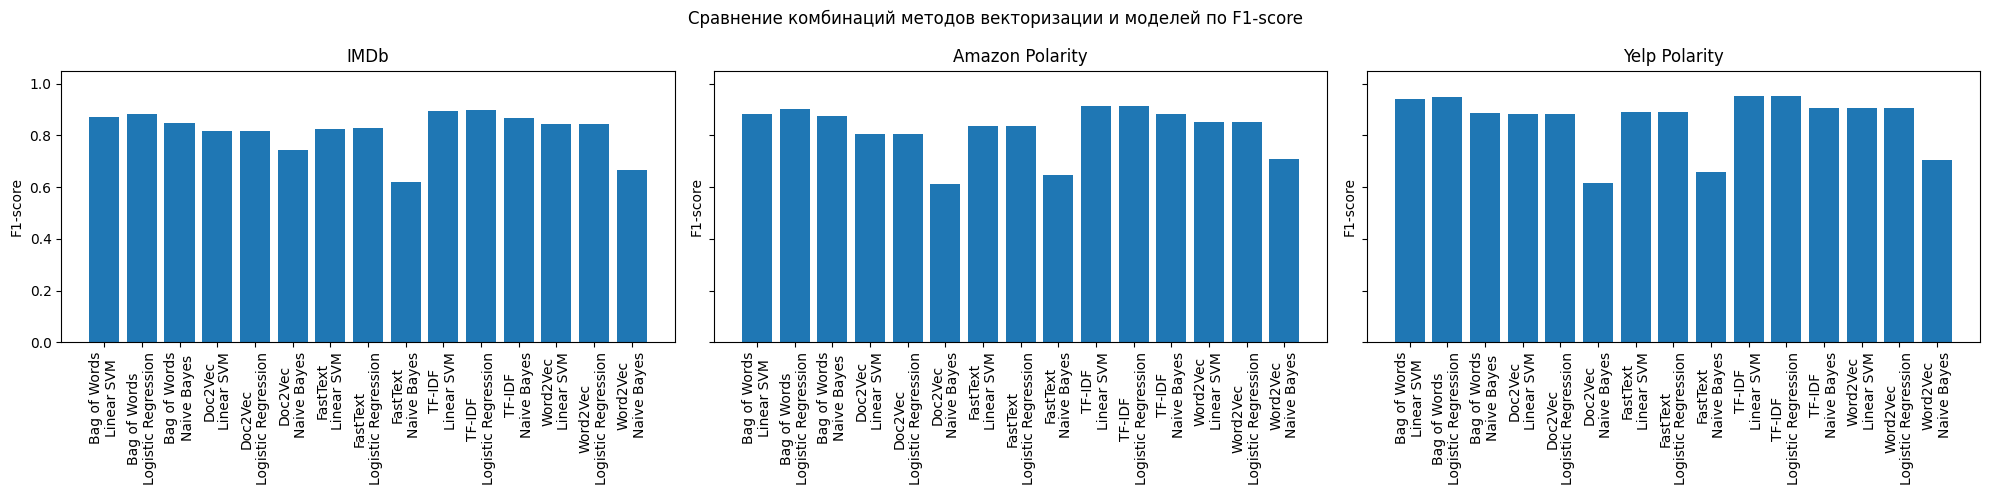

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, dataset_name in zip(axes, datasets_order):
    df_plot = viz_df[viz_df["dataset"] == dataset_name].copy()

    x = np.arange(len(df_plot))
    ax.bar(x, df_plot["f1"].values)
    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["label"], rotation=90)
    ax.set_ylabel("F1-score")
    ax.set_ylim(0, 1.05)

plt.suptitle("Сравнение комбинаций методов векторизации и моделей по F1-score")
plt.tight_layout()
plt.show()

### Bar chart по Accuracy

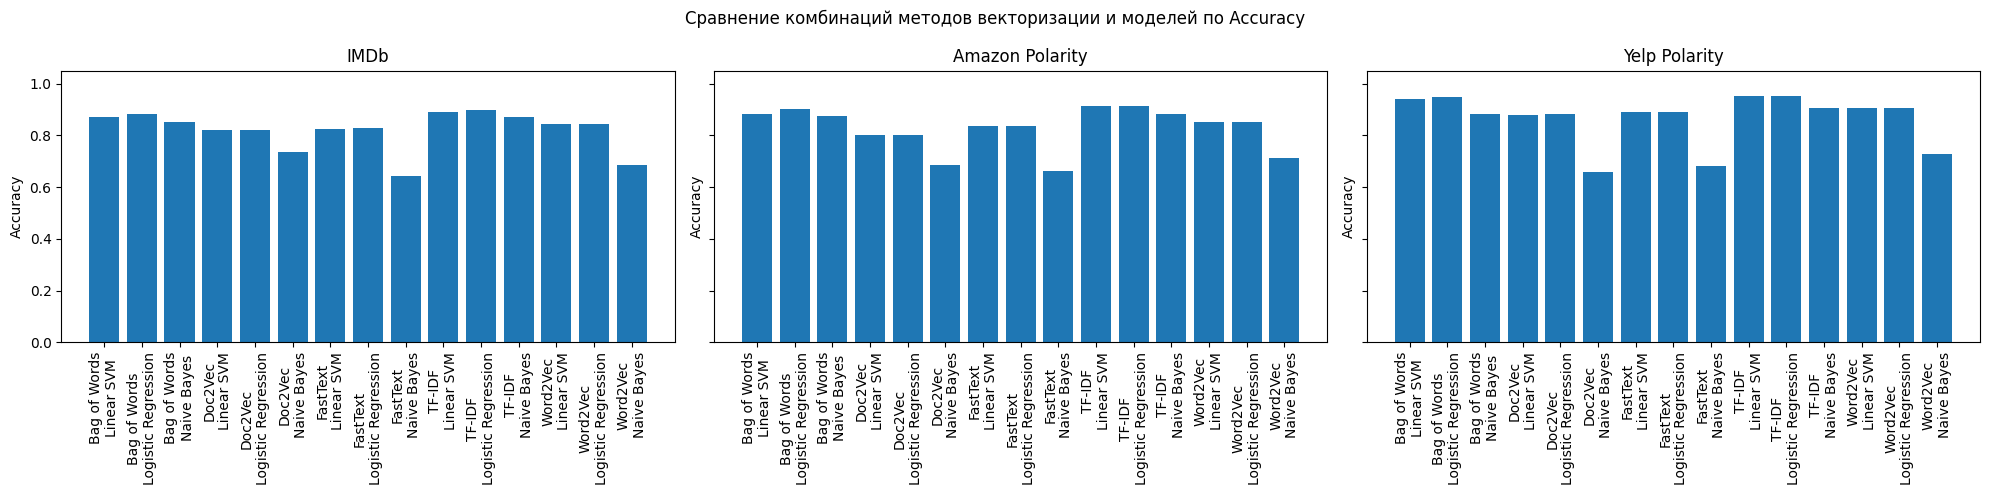

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, dataset_name in zip(axes, datasets_order):
    df_plot = viz_df[viz_df["dataset"] == dataset_name].copy()

    x = np.arange(len(df_plot))
    ax.bar(x, df_plot["accuracy"].values)
    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["label"], rotation=90)
    ax.set_ylabel("Accuracy")
    ax.set_ylim(0, 1.05)

plt.suptitle("Сравнение комбинаций методов векторизации и моделей по Accuracy")
plt.tight_layout()
plt.show()

### Bar chart по Precision

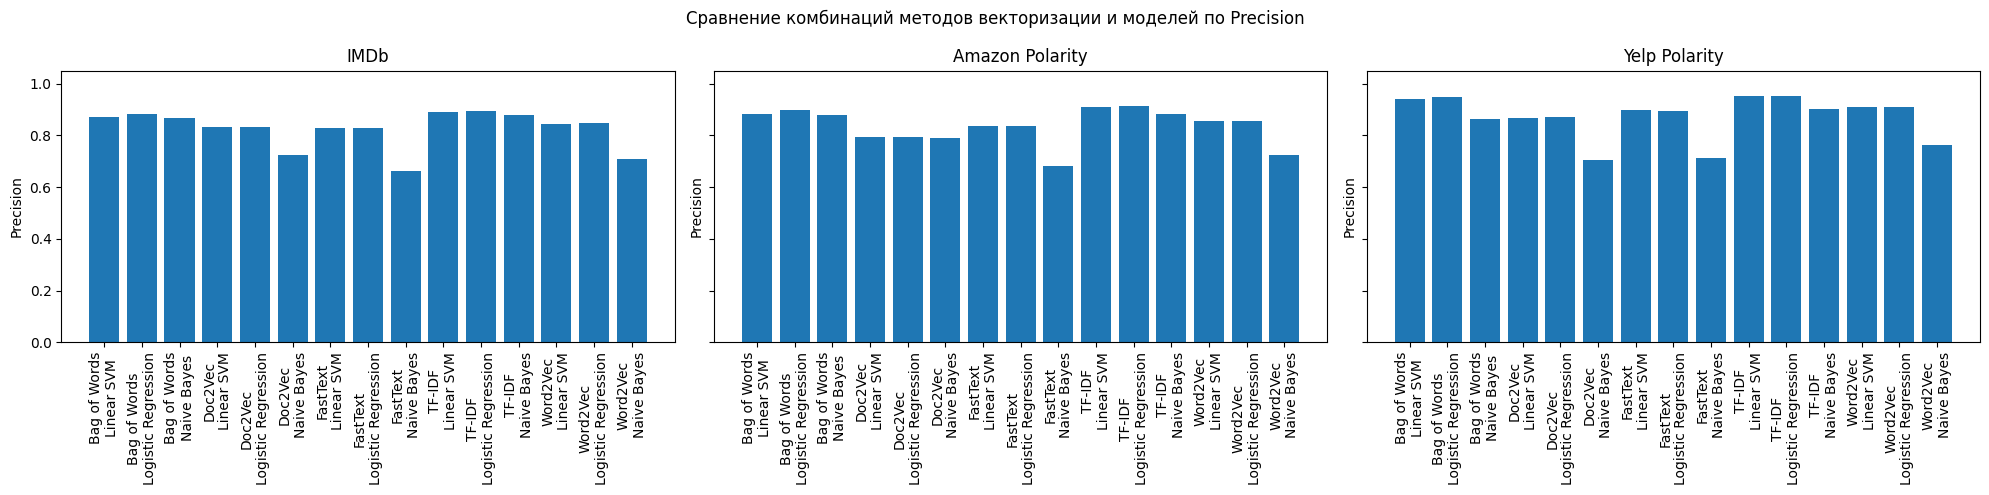

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, dataset_name in zip(axes, datasets_order):
    df_plot = viz_df[viz_df["dataset"] == dataset_name].copy()

    x = np.arange(len(df_plot))
    ax.bar(x, df_plot["precision"].values)
    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["label"], rotation=90)
    ax.set_ylabel("Precision")
    ax.set_ylim(0, 1.05)

plt.suptitle("Сравнение комбинаций методов векторизации и моделей по Precision")
plt.tight_layout()
plt.show()

### Bar chart по Recall

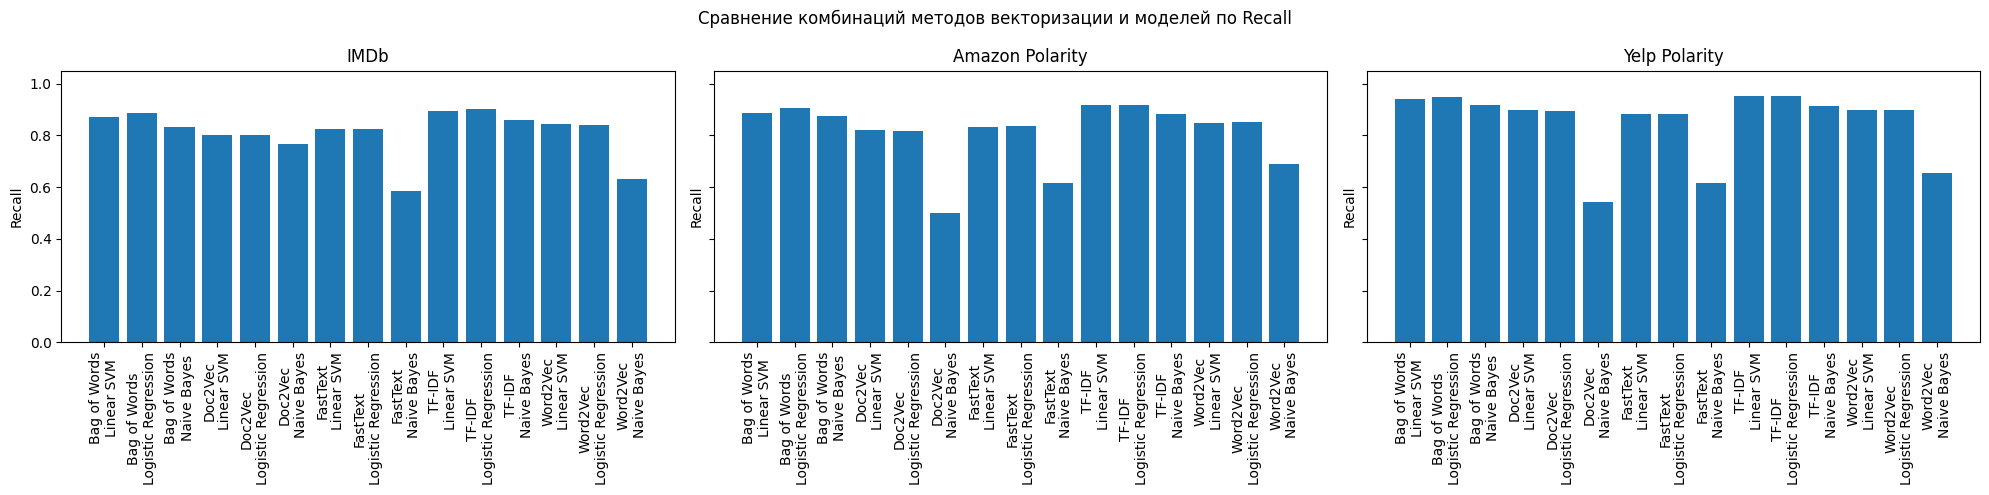

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5), sharey=True)

for ax, dataset_name in zip(axes, datasets_order):
    df_plot = viz_df[viz_df["dataset"] == dataset_name].copy()

    x = np.arange(len(df_plot))
    ax.bar(x, df_plot["recall"].values)
    ax.set_title(dataset_name)
    ax.set_xticks(x)
    ax.set_xticklabels(df_plot["label"], rotation=90)
    ax.set_ylabel("Recall")
    ax.set_ylim(0, 1.05)

plt.suptitle("Сравнение комбинаций методов векторизации и моделей по Recall")
plt.tight_layout()
plt.show()

### Heatmap F1-score

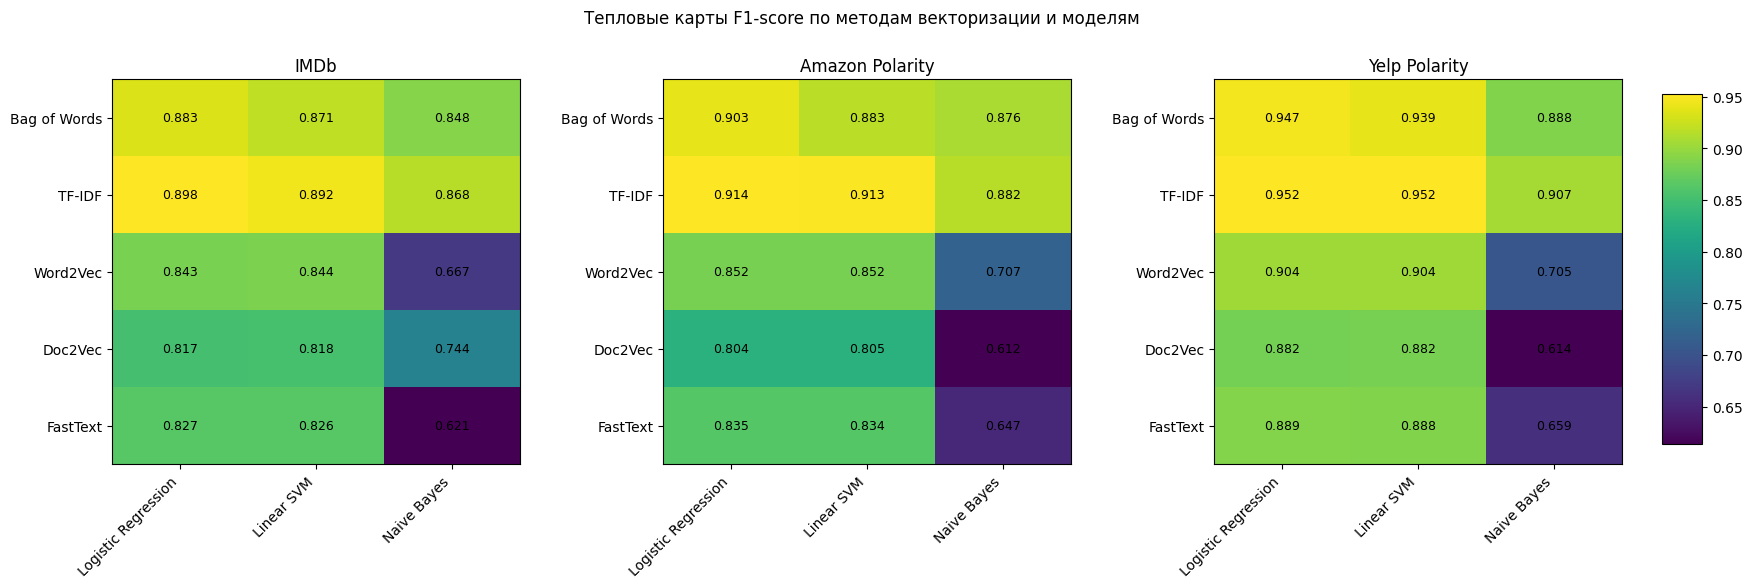

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(20, 5))
fig.subplots_adjust(wspace=0.35, right=0.88)

im = None

for ax, dataset_name in zip(axes, datasets_order):
    df_plot = viz_df[viz_df["dataset"] == dataset_name]
    pivot = df_plot.pivot(index="vectorizer", columns="model", values="f1")
    pivot = pivot.reindex(index=vectorizers_order, columns=models_order)

    im = ax.imshow(pivot.values, aspect="auto")
    ax.set_title(dataset_name)
    ax.set_xticks(np.arange(len(models_order)))
    ax.set_xticklabels(models_order, rotation=45, ha="right")
    ax.set_yticks(np.arange(len(vectorizers_order)))
    ax.set_yticklabels(vectorizers_order)

    for i in range(pivot.shape[0]):
        for j in range(pivot.shape[1]):
            value = pivot.iloc[i, j]
            ax.text(j, i, f"{value:.3f}", ha="center", va="center", fontsize=9)

cbar_ax = fig.add_axes([0.90, 0.15, 0.02, 0.7])
fig.colorbar(im, cax=cbar_ax)

fig.suptitle("Тепловые карты F1-score по методам векторизации и моделям", y=1.02)
plt.show()

### Таблица лучших комбинаций по каждому датасету

In [ ]:
best_val_models_df = (
    validation_results_df
    .sort_values(["dataset", "f1"], ascending=[True, False])
    .groupby("dataset", as_index=False)
    .first()[["dataset", "vectorizer", "model"]]
)

In [ ]:
best_results_df = best_val_models_df.merge(
    classification_results_df,
    on=["dataset", "vectorizer", "model"],
    how="left"
)

### Confusion Matrix для лучших моделей

Для наиболее успешных комбинаций по каждому датасету ниже строятся матрицы ошибок. Они позволяют оценить, насколько хорошо модель различает положительные и отрицательные отзывы и какие типы ошибок встречаются чаще.

In [ ]:
y_test_map = {
    "IMDb": y_test_imdb,
    "Amazon Polarity": y_test_amazon,
    "Yelp Polarity": y_test_yelp
}

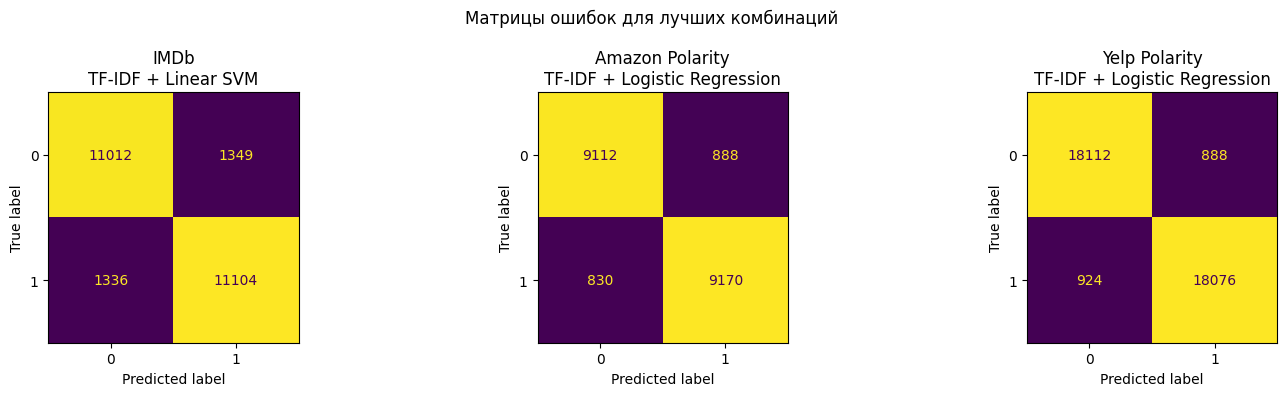

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, dataset_name in zip(axes, datasets_order):
    row = best_results_df[best_results_df["dataset"] == dataset_name].iloc[0]
    vectorizer_name = row["vectorizer"]
    model_name = row["model"]

    y_true = y_test_map[dataset_name]
    y_pred = predictions_store[(dataset_name, vectorizer_name, model_name)]

    cm = confusion_matrix(y_true, y_pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{dataset_name}\n{vectorizer_name} + {model_name}")

plt.suptitle("Матрицы ошибок для лучших комбинаций")
plt.tight_layout()
plt.show()

### Сопоставление с ориентирными результатами из литературы

Для сопоставления полученных результатов с опубликованными работами ниже приведены ориентирные метрики сильной трансформерной модели **DistilBERT-SST-2**. В статье Obiorah, Diri и Du (2025) эта модель сравнивалась на датасетах **IMDb**, **Amazon Polarity** и **Yelp Polarity** без дополнительного дообучения под каждый из них. В работе авторов DistilBERT-SST-2 показал лучшие результаты среди рассмотренных трансформерных моделей и был использован как ориентир для сравнения с результатами, полученными в данной работе.

| Датасет         | Ориентирная модель | Accuracy | F1-score | Источник                                                     |
| --------------- | ------------------ | -------: | -------: | ------------------------------------------------------------ |
| IMDb            | DistilBERT-SST-2   |     0.89 |   0.9418 | Obiorah et al., 2025 ([proceedings.informingscience.org][1]) |
| Amazon Polarity | DistilBERT-SST-2   |     0.85 |   0.8501 | Obiorah et al., 2025 ([proceedings.informingscience.org][1]) |
| Yelp Polarity   | DistilBERT-SST-2   |     0.85 |   0.8499 | Obiorah et al., 2025 ([proceedings.informingscience.org][1]) |

[1]: https://proceedings.informingscience.org/InSITE2025/InSITE2025Art23Obiorah11729.pdf "Comparative Evaluation of Traditional, Lexicon-Based, and Transformer Models for Sentiment Classification"


Сопоставление с ориентирными результатами из литературы показывает, что полученные в работе результаты находятся в общем русле современных исследований. При этом методы на признаках TF-IDF демонстрируют высокую практическую эффективность и в ряде случаев дают результаты, сопоставимые с сильными литературными ориентирами.

## Общий вывод

В ходе эксперимента было проведено сравнение пяти методов векторизации текста — Bag of Words, TF-IDF, Word2Vec, Doc2Vec и FastText — на трёх датасетах отзывов: IMDb, Amazon Polarity и Yelp Polarity. Для каждого метода векторизации были обучены модели Logistic Regression, Linear SVM и Naive Bayes, а качество оценивалось по метрикам Accuracy, Precision, Recall и F1-score.

Полученные результаты показывают, что наилучшие значения метрик во всех датасетах были достигнуты на признаках TF-IDF. При выборе лучших комбинаций по валидационной выборке для датасета IMDb наиболее успешной оказалась модель TF-IDF + Linear SVM, а для Amazon Polarity и Yelp Polarity — TF-IDF + Logistic Regression. На тестовой выборке эти комбинации также продемонстрировали наилучшие или близкие к наилучшим результаты, что подтверждает устойчивость данного подхода. В частности, для IMDb итоговое значение F1-score составило 0.8921 для TF-IDF + Linear SVM, для Amazon Polarity — 0.9143 для TF-IDF + Logistic Regression, для Yelp Polarity — 0.9523 для TF-IDF + Logistic Regression.

Метод Bag of Words также продемонстрировал высокое качество, однако в большинстве случаев немного уступал TF-IDF. Это подтверждает, что учёт информативности слов в корпусе позволяет получить более точное представление текста по сравнению с простым подсчётом частот.

Среди нейросетевых методов векторизации наилучшие результаты в данной работе показал Word2Vec. FastText в большинстве экспериментов оказался немного слабее Word2Vec, а Doc2Vec продемонстрировал наиболее низкие результаты среди плотных векторных представлений. Это показывает, что более сложный метод векторизации не всегда обеспечивает более высокое качество классификации, особенно при использовании стандартных параметров и классических моделей машинного обучения.

Также было установлено, что модели Logistic Regression и Linear SVM в целом превосходят Naive Bayes по качеству классификации. Особенно заметно это различие для плотных векторных представлений Word2Vec, FastText и Doc2Vec. Naive Bayes показал приемлемые результаты на частотных признаках, но оказался менее эффективным на нейросетевых представлениях текста.

Сопоставление с ориентирными результатами из литературы показывает, что методы на признаках TF-IDF остаются сильным и практически полезным решением для задачи классификации отзывов. При этом на более сложных корпусах трансформерные модели могут обеспечивать дополнительный прирост качества, особенно при использовании контекстных представлений текста. Таким образом, полученные результаты согласуются с общими тенденциями, представленными в современных исследованиях, и подтверждают, что классические методы векторизации по-прежнему сохраняют высокую эффективность в прикладных задачах анализа отзывов.

Анализ confusion matrix для лучших моделей показал, что ошибки классификации распределяются относительно равномерно, без выраженного смещения в сторону одного из классов. Это подтверждает, что лучшие модели адекватно различают положительные и отрицательные отзывы.

С точки зрения вычислительных характеристик частотные методы Bag of Words и TF-IDF оказались быстрее и проще в применении, однако требовали больше памяти на больших корпусах из-за высокой размерности разреженных матриц. Нейросетевые методы формировали компактные плотные представления, но требовали значительно большего времени обучения. Наиболее затратными по времени оказались Doc2Vec и FastText, особенно на крупном датасете Yelp Polarity.

Таким образом, по результатам исследования можно сделать вывод, что наиболее эффективными и практичными решениями в рамках данной работы оказались модели на признаках TF-IDF, прежде всего в сочетании с Logistic Regression и Linear SVM. Именно этот подход обеспечил наилучшее качество классификации и продемонстрировал устойчивые результаты на разных датасетах при разумных вычислительных затратах.

---

## Модель TextCNN

В дополнение к классическим моделям классификации в работе рассматривается глубокая нейросетевая архитектура **TextCNN**, предназначенная для классификации текстов. В данной модели текст представляется как последовательность токенов, каждому из которых сопоставляется обучаемый вектор признаков. Далее к матрице эмбеддингов применяются одномерные свёртки с несколькими размерами окна, что позволяет выделять локальные информативные шаблоны различной длины.

После слоя свёртки используется операция глобального максимума (**Global Max Pooling**), которая оставляет наиболее значимые признаки по каждому каналу. Затем полученное представление подаётся на полносвязный слой и выходной слой классификации.

В работе для обучения модели TextCNN используется функция потерь **CrossEntropyLoss**, оптимизатор **Adam**, а в качестве методов регуляризации применяются **dropout**, **weight decay** и **early stopping**. Критерием остановки обучения служит отсутствие улучшения качества на валидационной выборке в течение нескольких эпох.

### Настройка гиперпараметров

Для модели TextCNN автоматический подбор гиперпараметров выполняется только на датасете **IMDb** по обучающей и валидационной выборкам. Такой выбор обусловлен тем, что IMDb является достаточно репрезентативным корпусом для настройки модели: он содержит содержательные и сравнительно длинные отзывы, позволяет оценить поведение глубокой архитектуры на реальной задаче бинарной классификации и при этом остаётся вычислительно более доступным.  

После выбора лучшей конфигурации по валидационной выборке IMDb найденные гиперпараметры фиксируются и далее используются как базовые для обучения модели TextCNN на всех трёх датасетах — IMDb, Amazon Polarity и Yelp Polarity. Такой подход позволяет выполнить автоматическую настройку гиперпараметров и сохранить единую архитектурную основу эксперимента. При этом для крупных датасетов дополнительно используются облегчённые вычислительные настройки, что учитывается при интерпретации результатов.

In [ ]:
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from collections import Counter
from itertools import product

In [ ]:
torch.manual_seed(RANDOM_STATE)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(RANDOM_STATE)

### Подготовка данных для TextCNN

Для обучения модели TextCNN очищенные тексты преобразуются в последовательности токенов. На основе обучающей выборки каждого датасета формируется словарь, после чего каждый текст кодируется как последовательность целых индексов. Для обеспечения одинаковой длины входа используется ограничение максимальной длины последовательности и padding.

Важно отметить, что словарь строится отдельно для каждого датасета только по обучающей выборке. Это позволяет избежать утечки информации из валидационной и тестовой выборок.

In [ ]:
PAD_TOKEN = "<PAD>"
UNK_TOKEN = "<UNK>"

MAX_VOCAB_SIZE = 30000
MAX_LEN = 150
BATCH_SIZE = 32

def build_vocab(tokenized_texts, max_vocab_size=30000):
    counter = Counter()
    for tokens in tokenized_texts:
        counter.update(tokens)

    most_common = counter.most_common(max_vocab_size - 2)

    vocab = {
        PAD_TOKEN: 0,
        UNK_TOKEN: 1
    }

    for idx, (word, _) in enumerate(most_common, start=2):
        vocab[word] = idx

    return vocab

def encode_tokens(tokens, vocab, max_len=200):
    encoded = [vocab.get(token, vocab[UNK_TOKEN]) for token in tokens[:max_len]]
    if len(encoded) < max_len:
        encoded += [vocab[PAD_TOKEN]] * (max_len - len(encoded))
    return encoded

class TextDataset(Dataset):
    def __init__(self, tokenized_texts, labels, vocab, max_len=200):
        self.tokenized_texts = list(tokenized_texts)
        self.labels = list(labels)
        self.vocab = vocab
        self.max_len = max_len

    def __len__(self):
        return len(self.labels)

    def __getitem__(self, idx):
        encoded = encode_tokens(
            self.tokenized_texts[idx],
            self.vocab,
            max_len=self.max_len
        )
        x = torch.tensor(encoded, dtype=torch.long)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y

In [ ]:
def prepare_textcnn_data(train_tokens, val_tokens, test_tokens, y_train, y_val, y_test,
                         max_vocab_size=30000, max_len=200, batch_size=64):
    vocab = build_vocab(train_tokens, max_vocab_size=max_vocab_size)

    train_dataset = TextDataset(train_tokens, y_train, vocab, max_len=max_len)
    val_dataset = TextDataset(val_tokens, y_val, vocab, max_len=max_len)
    test_dataset = TextDataset(test_tokens, y_test, vocab, max_len=max_len)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2, pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

    return vocab, train_loader, val_loader, test_loader

### Архитектура TextCNN

В модели используется обучаемый слой эмбеддингов, несколько одномерных сверточных слоёв с различными размерами ядра, операция глобального максимума и полносвязный выходной слой. Такая архитектура позволяет выделять локальные текстовые шаблоны различной длины и использовать их для классификации документа.

In [ ]:
class TextCNN(nn.Module):
    def __init__(
        self,
        vocab_size,
        embed_dim=100,
        num_classes=2,
        kernel_sizes=(3, 4, 5),
        num_filters=100,
        dropout=0.5
    ):
        super().__init__()

        self.embedding = nn.Embedding(vocab_size, embed_dim, padding_idx=0)

        self.convs = nn.ModuleList([
            nn.Conv1d(
                in_channels=embed_dim,
                out_channels=num_filters,
                kernel_size=k
            )
            for k in kernel_sizes
        ])

        self.dropout = nn.Dropout(dropout)
        self.fc = nn.Linear(num_filters * len(kernel_sizes), num_classes)

    def forward(self, x):
        x = self.embedding(x)
        x = x.permute(0, 2, 1)

        conv_outputs = []
        for conv in self.convs:
            c = torch.relu(conv(x))
            p = torch.max(c, dim=2).values
            conv_outputs.append(p)

        x = torch.cat(conv_outputs, dim=1)
        x = self.dropout(x)
        x = self.fc(x)

        return x

### Параметры обучения

Для обучения модели TextCNN используются функция потерь `CrossEntropyLoss`, оптимизатор `Adam`, L2-регуляризация через `weight_decay`, dropout и ранняя остановка (`early stopping`). Критерием выбора лучшей модели служит значение F1-score на валидационной выборке.


В рамках экспериментов для модели TextCNN фиксировалось время полного цикла её применения на каждом датасете, включающего обучение сети и последующую итоговую оценку на валидационной и тестовой выборках. При автоматическом подборе гиперпараметров на IMDb дополнительно измерялось время обучения каждой отдельной конфигурации модели.

In [ ]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

NUM_EPOCHS = 4
PATIENCE = 1
WEIGHT_DECAY = 1e-4

print("DEVICE:", DEVICE)

DEVICE: cuda


In [ ]:
def evaluate_textcnn(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            total_loss += loss.item() * X_batch.size(0)

            preds = torch.argmax(logits, dim=1)

            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(y_batch.cpu().numpy())

    avg_loss = total_loss / len(dataloader.dataset)

    metrics = {
        "loss": avg_loss,
        "accuracy": accuracy_score(all_labels, all_preds),
        "precision": precision_score(all_labels, all_preds, zero_division=0),
        "recall": recall_score(all_labels, all_preds, zero_division=0),
        "f1": f1_score(all_labels, all_preds, zero_division=0)
    }

    return metrics, all_preds, all_labels

In [ ]:
def train_textcnn(model, train_loader, val_loader, criterion, optimizer, device, num_epochs=8, patience=2):
    best_state = None
    best_val_f1 = -1
    patience_counter = 0

    history = []

    for epoch in range(1, num_epochs + 1):
        model.train()
        total_train_loss = 0

        for X_batch, y_batch in train_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            total_train_loss += loss.item() * X_batch.size(0)

        train_loss = total_train_loss / len(train_loader.dataset)

        val_metrics, _, _ = evaluate_textcnn(model, val_loader, criterion, device)

        history.append({
            "epoch": epoch,
            "train_loss": train_loss,
            "val_loss": val_metrics["loss"],
            "val_accuracy": val_metrics["accuracy"],
            "val_precision": val_metrics["precision"],
            "val_recall": val_metrics["recall"],
            "val_f1": val_metrics["f1"]
        })

        print(
            f"Epoch {epoch}: "
            f"train_loss={train_loss:.4f}, "
            f"val_loss={val_metrics['loss']:.4f}, "
            f"val_f1={val_metrics['f1']:.4f}"
        )

        if val_metrics["f1"] > best_val_f1:
            best_val_f1 = val_metrics["f1"]
            best_state = copy.deepcopy(model.state_dict())
            patience_counter = 0
        else:
            patience_counter += 1

        if patience_counter >= patience:
            print("Early stopping triggered.")
            break

    if best_state is not None:
        model.load_state_dict(best_state)

    history_df = pd.DataFrame(history)
    return model, history_df

### Автоматический подбор гиперпараметров на IMDb

Для настройки модели TextCNN выполняется автоматический перебор нескольких конфигураций гиперпараметров на датасете IMDb. В подбор включаются размерность эмбеддингов (`embed_dim`), число сверточных фильтров (`num_filters`), коэффициент dropout (`dropout`) и скорость обучения (`learning_rate`). Лучшая конфигурация определяется по максимальному значению F1-score на валидационной выборке.

In [ ]:
imdb_vocab, imdb_train_loader, imdb_val_loader, imdb_test_loader = prepare_textcnn_data(
    imdb_train_tokens, imdb_val_tokens, imdb_test_tokens,
    y_train_imdb, y_val_imdb, y_test_imdb,
    max_vocab_size=MAX_VOCAB_SIZE,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE
)

print("Размер словаря IMDb:", len(imdb_vocab))
print("Train batches:", len(imdb_train_loader))
print("Val batches:", len(imdb_val_loader))
print("Test batches:", len(imdb_test_loader))

Размер словаря IMDb: 30000
Train batches: 623
Val batches: 156
Test batches: 776


In [ ]:
param_grid = {
    "embed_dim": [64, 100],
    "num_filters": [64],
    "dropout": [0.3, 0.5],
    "learning_rate": [1e-3]
}

all_combinations = list(product(
    param_grid["embed_dim"],
    param_grid["num_filters"],
    param_grid["dropout"],
    param_grid["learning_rate"]
))

print("Количество конфигураций для перебора:", len(all_combinations))

Количество конфигураций для перебора: 4


In [ ]:
grid_results = []

for embed_dim, num_filters, dropout, lr in all_combinations:
    print("=" * 70)
    print(
        f"Testing config: "
        f"embed_dim={embed_dim}, "
        f"num_filters={num_filters}, "
        f"dropout={dropout}, "
        f"lr={lr}"
    )

    model = TextCNN(
        vocab_size=len(imdb_vocab),
        embed_dim=embed_dim,
        num_classes=2,
        kernel_sizes=(3, 4, 5),
        num_filters=num_filters,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=lr,
        weight_decay=WEIGHT_DECAY
    )

    start_time = time.perf_counter()

    model, history_df = train_textcnn(
        model=model,
        train_loader=imdb_train_loader,
        val_loader=imdb_val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        num_epochs=NUM_EPOCHS,
        patience=PATIENCE
    )

    elapsed_time = time.perf_counter() - start_time

    val_metrics, _, _ = evaluate_textcnn(model, imdb_val_loader, criterion, DEVICE)

    grid_results.append({
        "embed_dim": embed_dim,
        "num_filters": num_filters,
        "dropout": dropout,
        "learning_rate": lr,
        "val_accuracy": round(val_metrics["accuracy"], 4),
        "val_precision": round(val_metrics["precision"], 4),
        "val_recall": round(val_metrics["recall"], 4),
        "val_f1": round(val_metrics["f1"], 4),
        "val_loss": round(val_metrics["loss"], 4),
        "epochs_ran": len(history_df),
        "time_sec": round(elapsed_time, 2)
    })

Testing config: embed_dim=64, num_filters=64, dropout=0.3, lr=0.001
Epoch 1: train_loss=0.6417, val_loss=0.5330, val_f1=0.7288
Epoch 2: train_loss=0.5192, val_loss=0.4700, val_f1=0.7895
Epoch 3: train_loss=0.4527, val_loss=0.4253, val_f1=0.8126
Epoch 4: train_loss=0.4009, val_loss=0.3977, val_f1=0.8148
Testing config: embed_dim=64, num_filters=64, dropout=0.5, lr=0.001
Epoch 1: train_loss=0.6806, val_loss=0.5585, val_f1=0.7408
Epoch 2: train_loss=0.5712, val_loss=0.5076, val_f1=0.7591
Epoch 3: train_loss=0.5059, val_loss=0.4507, val_f1=0.7956
Epoch 4: train_loss=0.4420, val_loss=0.4084, val_f1=0.8081
Testing config: embed_dim=100, num_filters=64, dropout=0.3, lr=0.001
Epoch 1: train_loss=0.6141, val_loss=0.4948, val_f1=0.7721
Epoch 2: train_loss=0.4961, val_loss=0.4451, val_f1=0.8005
Epoch 3: train_loss=0.4362, val_loss=0.4129, val_f1=0.8160
Epoch 4: train_loss=0.3824, val_loss=0.3841, val_f1=0.8289
Testing config: embed_dim=100, num_filters=64, dropout=0.5, lr=0.001
Epoch 1: train_los

In [ ]:
grid_results_df = pd.DataFrame(grid_results)
grid_results_df = grid_results_df.sort_values(
    ["val_f1", "val_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

grid_results_df

,embed_dim,num_filters,dropout,learning_rate,val_accuracy,val_precision,val_recall,val_f1,val_loss,epochs_ran,time_sec
0,100,64,0.3,0.001,0.8314,0.8429,0.8152,0.8289,0.3841,4,579.15
1,100,64,0.5,0.001,0.8027,0.7666,0.8713,0.8156,0.4313,4,580.07
2,64,64,0.3,0.001,0.8213,0.8473,0.7848,0.8148,0.3977,4,32.38
3,64,64,0.5,0.001,0.8127,0.8298,0.7876,0.8081,0.4084,4,24.60


In [ ]:
best_params = grid_results_df.iloc[0].to_dict()
best_params

{'embed_dim': 100.0,
 'num_filters': 64.0,
 'dropout': 0.3,
 'learning_rate': 0.001,
 'val_accuracy': 0.8314,
 'val_precision': 0.8429,
 'val_recall': 0.8152,
 'val_f1': 0.8289,
 'val_loss': 0.3841,
 'epochs_ran': 4.0,
 'time_sec': 579.15}

In [ ]:
BEST_EMBED_DIM = int(best_params["embed_dim"])
BEST_NUM_FILTERS = int(best_params["num_filters"])
BEST_DROPOUT = float(best_params["dropout"])
BEST_LR = float(best_params["learning_rate"])

print("Лучшие параметры TextCNN:")
print("embed_dim =", BEST_EMBED_DIM)
print("num_filters =", BEST_NUM_FILTERS)
print("dropout =", BEST_DROPOUT)
print("learning_rate =", BEST_LR)

Лучшие параметры TextCNN:
embed_dim = 100
num_filters = 64
dropout = 0.3
learning_rate = 0.001


### Дополнительный анализ длины последовательностей для выбора `MAX_LEN`

Так как качество модели TextCNN зависит от максимальной длины входной последовательности, дополнительно проводится анализ распределения длины отзывов в словах для датасетов Amazon Polarity и Yelp Polarity. Это позволяет оценить, какая доля текстов обрезается при различных значениях `MAX_LEN`, и обосновать выбранные параметры усечения.

Кроме того, на небольшой стратифицированной подвыборке Yelp Polarity проводится пилотный эксперимент, в котором сравнивается качество TextCNN при разных значениях `MAX_LEN`. Дополнительно анализируется изменение качества по эпохам, что позволяет обосновать выбор числа эпох обучения.

In [ ]:
def get_text_lengths(series):
    return series.astype(str).str.split().apply(len)

amazon_lengths = get_text_lengths(amazon_train["text_clean"])
yelp_lengths = get_text_lengths(yelp_train["text_clean"])

length_stats_textcnn_df = pd.DataFrame([
    {
        "dataset": "Amazon Polarity",
        "mean_words": round(amazon_lengths.mean(), 2),
        "median_words": int(amazon_lengths.median()),
        "p90_words": int(amazon_lengths.quantile(0.90)),
        "p95_words": int(amazon_lengths.quantile(0.95)),
        "p99_words": int(amazon_lengths.quantile(0.99)),
        "max_words": int(amazon_lengths.max())
    },
    {
        "dataset": "Yelp Polarity",
        "mean_words": round(yelp_lengths.mean(), 2),
        "median_words": int(yelp_lengths.median()),
        "p90_words": int(yelp_lengths.quantile(0.90)),
        "p95_words": int(yelp_lengths.quantile(0.95)),
        "p99_words": int(yelp_lengths.quantile(0.99)),
        "max_words": int(yelp_lengths.max())
    }
])

length_stats_textcnn_df

,dataset,mean_words,median_words,p90_words,p95_words,p99_words,max_words
0,Amazon Polarity,79.45,71,146,163,183,219
1,Yelp Polarity,136.16,99,289,381,624,1046


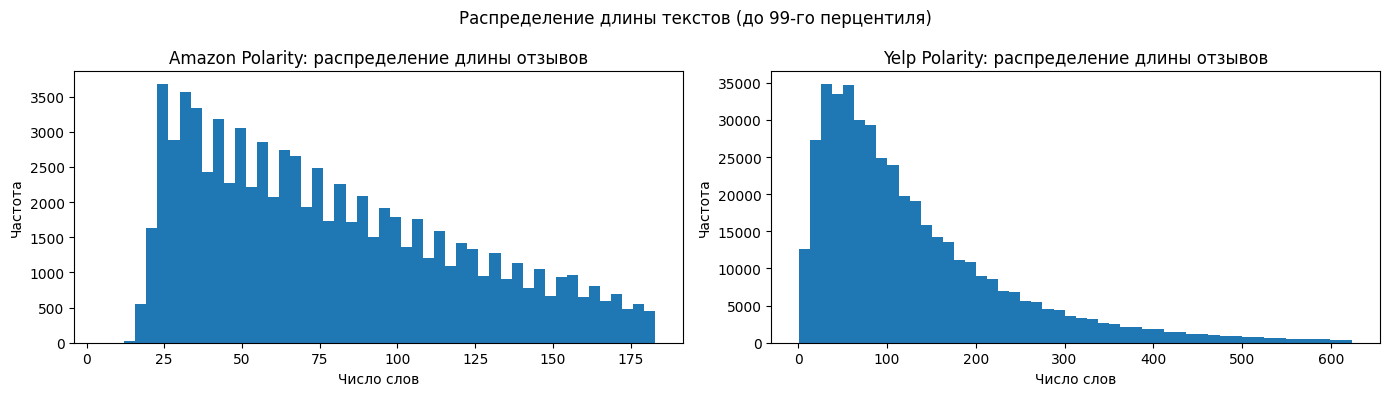

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

amazon_clip = amazon_lengths[amazon_lengths <= amazon_lengths.quantile(0.99)]
yelp_clip = yelp_lengths[yelp_lengths <= yelp_lengths.quantile(0.99)]

axes[0].hist(amazon_clip, bins=50)
axes[0].set_title("Amazon Polarity: распределение длины отзывов")
axes[0].set_xlabel("Число слов")
axes[0].set_ylabel("Частота")

axes[1].hist(yelp_clip, bins=50)
axes[1].set_title("Yelp Polarity: распределение длины отзывов")
axes[1].set_xlabel("Число слов")
axes[1].set_ylabel("Частота")

plt.suptitle("Распределение длины текстов (до 99-го перцентиля)")
plt.tight_layout()
plt.show()

In [ ]:
thresholds = [60, 100, 150, 200]

rows = []
for dataset_name, lengths in [
    ("Amazon Polarity", amazon_lengths),
    ("Yelp Polarity", yelp_lengths)
]:
    total = len(lengths)
    row = {"dataset": dataset_name}
    for threshold in thresholds:
        row[f"> {threshold} слов, %"] = round((lengths > threshold).sum() / total * 100, 2)
    rows.append(row)

length_thresholds_df = pd.DataFrame(rows)
length_thresholds_df

,dataset,"> 60 слов, %","> 100 слов, %","> 150 слов, %","> 200 слов, %"
0,Amazon Polarity,58.69,29.92,8.64,0.05
1,Yelp Polarity,69.83,49.30,31.76,20.61


In [ ]:
amazon_over_100 = length_thresholds_df.loc[
    length_thresholds_df["dataset"] == "Amazon Polarity", "> 100 слов, %"
].iloc[0]

yelp_over_60 = length_thresholds_df.loc[
    length_thresholds_df["dataset"] == "Yelp Polarity", "> 60 слов, %"
].iloc[0]

yelp_over_100 = length_thresholds_df.loc[
    length_thresholds_df["dataset"] == "Yelp Polarity", "> 100 слов, %"
].iloc[0]

yelp_over_150 = length_thresholds_df.loc[
    length_thresholds_df["dataset"] == "Yelp Polarity", "> 150 слов, %"
].iloc[0]

print(
    f"Amazon Polarity: доля отзывов длиннее 100 слов составляет {amazon_over_100} %."
)
print(
    f"Yelp Polarity: доля отзывов длиннее 60 слов составляет {yelp_over_60} %, "
    f"длиннее 100 слов — {yelp_over_100} %, длиннее 150 слов — {yelp_over_150} %."
)

Amazon Polarity: доля отзывов длиннее 100 слов составляет 29.92 %.
Yelp Polarity: доля отзывов длиннее 60 слов составляет 69.83 %, длиннее 100 слов — 49.3 %, длиннее 150 слов — 31.76 %.


### Пилотный эксперимент на малой подвыборке Yelp Polarity

Так как именно для Yelp Polarity выбранное значение `MAX_LEN=60` вызывает наибольшие сомнения, дополнительно проводится пилотный эксперимент на небольшой стратифицированной подвыборке. Цель эксперимента — оценить, как изменение `MAX_LEN` влияет на качество модели TextCNN, а также проследить изменение качества по эпохам обучения без запуска полного ресурсоёмкого эксперимента на всём датасете.

In [ ]:
PILOT_TRAIN_SIZE = 2000
PILOT_VAL_SIZE = 1000

pilot_train_idx, _ = train_test_split(
    np.arange(len(yelp_train_tokens)),
    train_size=PILOT_TRAIN_SIZE,
    stratify=y_train_yelp,
    random_state=RANDOM_STATE
)

pilot_val_idx, _ = train_test_split(
    np.arange(len(yelp_val_tokens)),
    train_size=PILOT_VAL_SIZE,
    stratify=y_val_yelp,
    random_state=RANDOM_STATE
)

yelp_train_tokens_pilot = yelp_train_tokens.iloc[pilot_train_idx].reset_index(drop=True)
yelp_val_tokens_pilot = yelp_val_tokens.iloc[pilot_val_idx].reset_index(drop=True)

y_train_yelp_pilot = y_train_yelp.iloc[pilot_train_idx].reset_index(drop=True)
y_val_yelp_pilot = y_val_yelp.iloc[pilot_val_idx].reset_index(drop=True)

print("Pilot Yelp train size:", len(yelp_train_tokens_pilot))
print("Pilot Yelp val size:", len(yelp_val_tokens_pilot))
print("Train class balance:")
print(y_train_yelp_pilot.value_counts(normalize=True).sort_index())
print("Val class balance:")
print(y_val_yelp_pilot.value_counts(normalize=True).sort_index())

Pilot Yelp train size: 2000
Pilot Yelp val size: 1000
Train class balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64
Val class balance:
label
0    0.5
1    0.5
Name: proportion, dtype: float64


In [ ]:
def prepare_textcnn_data_pilot(
    train_tokens, val_tokens, y_train, y_val,
    max_vocab_size=10000, max_len=100, batch_size=32
):
    vocab = build_vocab(train_tokens, max_vocab_size=max_vocab_size)

    train_dataset = TextDataset(train_tokens, y_train, vocab, max_len=max_len)
    val_dataset = TextDataset(val_tokens, y_val, vocab, max_len=max_len)

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=0,
        pin_memory=False
    )
    val_loader = DataLoader(
        val_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=0,
        pin_memory=False
    )

    return vocab, train_loader, val_loader

In [ ]:
PILOT_DEVICE = torch.device("cpu")

def run_textcnn_maxlen_pilot(
    max_len,
    embed_dim=BEST_EMBED_DIM,
    num_filters=BEST_NUM_FILTERS,
    dropout=BEST_DROPOUT,
    learning_rate=BEST_LR,
    max_vocab_size=10000,
    batch_size=32,
    num_epochs=3,
    patience=1
):
    vocab, train_loader, val_loader = prepare_textcnn_data_pilot(
        yelp_train_tokens_pilot,
        yelp_val_tokens_pilot,
        y_train_yelp_pilot,
        y_val_yelp_pilot,
        max_vocab_size=max_vocab_size,
        max_len=max_len,
        batch_size=batch_size
    )

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        num_classes=2,
        kernel_sizes=(3, 4, 5),
        num_filters=num_filters,
        dropout=dropout
    ).to(PILOT_DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    start_time = time.perf_counter()

    model, history_df = train_textcnn(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=PILOT_DEVICE,
        num_epochs=num_epochs,
        patience=patience
    )

    elapsed_time = time.perf_counter() - start_time

    val_metrics, _, _ = evaluate_textcnn(model, val_loader, criterion, PILOT_DEVICE)

    return {
        "max_len": max_len,
        "val_accuracy": round(val_metrics["accuracy"], 4),
        "val_precision": round(val_metrics["precision"], 4),
        "val_recall": round(val_metrics["recall"], 4),
        "val_f1": round(val_metrics["f1"], 4),
        "val_loss": round(val_metrics["loss"], 4),
        "epochs_ran": len(history_df),
        "time_sec": round(elapsed_time, 2)
    }, history_df

In [ ]:
pilot_max_len_results = []
pilot_histories_by_len = {}

for max_len in [50, 100, 150, 200]:
    print("=" * 70)
    print(f"Testing Yelp pilot with MAX_LEN={max_len}")

    result, history_df = run_textcnn_maxlen_pilot(max_len=max_len)

    pilot_max_len_results.append(result)
    pilot_histories_by_len[max_len] = history_df

pilot_max_len_df = pd.DataFrame(pilot_max_len_results).sort_values(
    ["val_f1", "val_accuracy"],
    ascending=[False, False]
).reset_index(drop=True)

pilot_max_len_df

Testing Yelp pilot with MAX_LEN=50
Epoch 1: train_loss=0.7219, val_loss=0.6273, val_f1=0.7017
Epoch 2: train_loss=0.5401, val_loss=0.6057, val_f1=0.7215
Epoch 3: train_loss=0.4357, val_loss=0.5454, val_f1=0.7181
Early stopping triggered.
Testing Yelp pilot with MAX_LEN=100
Epoch 1: train_loss=0.7369, val_loss=0.5771, val_f1=0.6659
Epoch 2: train_loss=0.5357, val_loss=0.5648, val_f1=0.7450
Epoch 3: train_loss=0.4299, val_loss=0.4801, val_f1=0.7821
Testing Yelp pilot with MAX_LEN=150
Epoch 1: train_loss=0.7155, val_loss=0.5826, val_f1=0.7570
Epoch 2: train_loss=0.5213, val_loss=0.4998, val_f1=0.7393
Early stopping triggered.
Testing Yelp pilot with MAX_LEN=200
Epoch 1: train_loss=0.6940, val_loss=0.5784, val_f1=0.7612
Epoch 2: train_loss=0.5028, val_loss=0.5017, val_f1=0.7694
Epoch 3: train_loss=0.4095, val_loss=0.4925, val_f1=0.7828


,max_len,val_accuracy,val_precision,val_recall,val_f1,val_loss,epochs_ran,time_sec
0,200,0.753,0.6986,0.890,0.7828,0.4925,3,15.21
1,100,0.781,0.7782,0.786,0.7821,0.4801,3,8.99
2,150,0.722,0.6724,0.866,0.7570,0.5826,2,7.15
3,50,0.658,0.6085,0.886,0.7215,0.6057,3,12.04


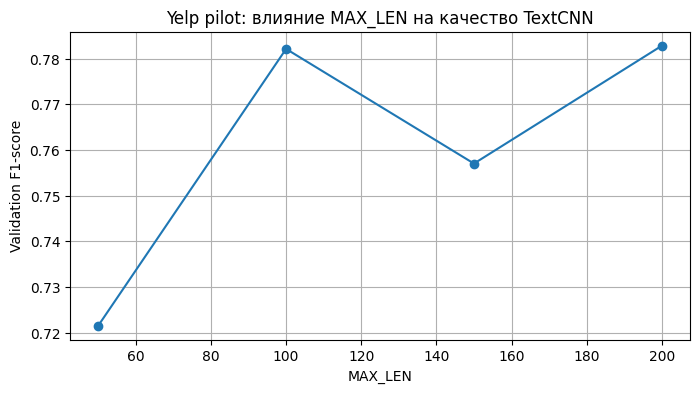

In [ ]:
plot_df = pilot_max_len_df.sort_values("max_len").reset_index(drop=True)

plt.figure(figsize=(8, 4))
plt.plot(plot_df["max_len"], plot_df["val_f1"], marker="o")
plt.xlabel("MAX_LEN")
plt.ylabel("Validation F1-score")
plt.title("Yelp pilot: влияние MAX_LEN на качество TextCNN")
plt.grid(True)
plt.show()

In [ ]:
best_max_len_from_pilot = int(pilot_max_len_df.iloc[0]["max_len"])
best_val_f1_from_pilot = float(pilot_max_len_df.iloc[0]["val_f1"])

print(f"Лучшее значение MAX_LEN в пилоте: {best_max_len_from_pilot}")
print(f"Лучший validation F1-score: {best_val_f1_from_pilot}")

Лучшее значение MAX_LEN в пилоте: 200
Лучший validation F1-score: 0.7828


### Пилотный анализ числа эпох для Yelp Polarity

Для дополнительного обоснования числа эпох обучения проводится отдельная проверка на той же подвыборке Yelp Polarity. Модель обучается в течение нескольких эпох без агрессивной ранней остановки, после чего анализируется динамика F1-score на валидационной выборке. Это позволяет оценить, выходит ли качество на плато уже на ранних эпохах или продолжает заметно расти.

In [ ]:
def run_textcnn_epoch_pilot(
    max_len,
    embed_dim=BEST_EMBED_DIM,
    num_filters=BEST_NUM_FILTERS,
    dropout=BEST_DROPOUT,
    learning_rate=BEST_LR,
    max_vocab_size=10000,
    batch_size=32,
    num_epochs=5
):
    vocab, train_loader, val_loader = prepare_textcnn_data_pilot(
        yelp_train_tokens_pilot,
        yelp_val_tokens_pilot,
        y_train_yelp_pilot,
        y_val_yelp_pilot,
        max_vocab_size=max_vocab_size,
        max_len=max_len,
        batch_size=batch_size
    )

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        num_classes=2,
        kernel_sizes=(3, 4, 5),
        num_filters=num_filters,
        dropout=dropout
    ).to(PILOT_DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    model, history_df = train_textcnn(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=PILOT_DEVICE,
        num_epochs=num_epochs,
        patience=num_epochs
    )

    return history_df

In [ ]:
epoch_pilot_max_len = best_max_len_from_pilot

epoch_history_df = run_textcnn_epoch_pilot(
    max_len=epoch_pilot_max_len,
    num_epochs=5
)

epoch_history_df

Epoch 1: train_loss=0.7118, val_loss=0.5689, val_f1=0.7587
Epoch 2: train_loss=0.5141, val_loss=0.4920, val_f1=0.7662
Epoch 3: train_loss=0.4048, val_loss=0.4417, val_f1=0.8219
Epoch 4: train_loss=0.3215, val_loss=0.3972, val_f1=0.8161
Epoch 5: train_loss=0.2450, val_loss=0.3752, val_f1=0.8259


,epoch,train_loss,val_loss,val_accuracy,val_precision,val_recall,val_f1
0,1,0.711792,0.568883,0.764,0.776151,0.742,0.758691
1,2,0.514067,0.491985,0.773,0.789809,0.744,0.766220
2,3,0.404842,0.441672,0.815,0.792208,0.854,0.821944
3,4,0.321472,0.397230,0.822,0.844017,0.790,0.816116
4,5,0.245028,0.375217,0.833,0.862745,0.792,0.825860


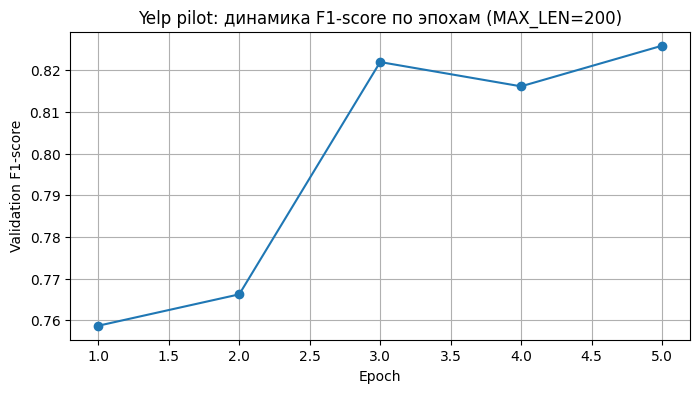

In [ ]:
plt.figure(figsize=(8, 4))
plt.plot(epoch_history_df["epoch"], epoch_history_df["val_f1"], marker="o")
plt.xlabel("Epoch")
plt.ylabel("Validation F1-score")
plt.title(f"Yelp pilot: динамика F1-score по эпохам (MAX_LEN={epoch_pilot_max_len})")
plt.grid(True)
plt.show()

In [ ]:
best_epoch_row = epoch_history_df.loc[epoch_history_df["val_f1"].idxmax()]

print(
    f"Максимальное значение validation F1-score в пилоте достигнуто на эпохе "
    f"{int(best_epoch_row['epoch'])}: {best_epoch_row['val_f1']:.4f}"
)

Максимальное значение validation F1-score в пилоте достигнуто на эпохе 5: 0.8259


### Интерпретация результатов дополнительного анализа и обоснование выбранных параметров

Проведённый дополнительный анализ показал, что выбор параметров усечения последовательностей действительно влияет на качество модели TextCNN и требует отдельного обоснования.

Для Amazon Polarity распределение длин отзывов показывает, что при значении `MAX_LEN=100` часть текстов обрезается: около 29.92% отзывов длиннее 100 слов. Однако с учётом средней длины текстов, более компактного характера отзывов по сравнению с Yelp Polarity и необходимости ограничения вычислительных затрат значение `MAX_LEN=100` в данной работе рассматривается как компромиссное. Оно позволяет сохранить существенную часть текстовой информации и одновременно удержать обучение модели в вычислительно доступных пределах.

Для Yelp Polarity дополнительный анализ показал, что усечение до `MAX_LEN=60` является значительно более жёстким: около 69.83% отзывов длиннее 60 слов, 49.3% — длиннее 100 слов, 31.76% — длиннее 150 слов. Пилотный эксперимент на малой стратифицированной подвыборке подтвердил, что слишком малые значения `MAX_LEN` ухудшают качество модели, а наилучшие результаты в пилоте были достигнуты при `MAX_LEN=100` и `MAX_LEN=200`. Это означает, что с методической точки зрения более длинные последовательности для Yelp Polarity были бы предпочтительнее.

Тем не менее в основном эксперименте для Yelp Polarity было сохранено значение `MAX_LEN=60`. Такой выбор связан не с тем, что данный параметр является оптимальным, а с ограничениями доступных вычислительных ресурсов. В условиях работы увеличение длины последовательности для крупного датасета Yelp Polarity существенно повышало время обучения и риск прерывания вычислений. Поэтому итоговое значение `MAX_LEN=60` следует рассматривать как вынужденный компромиссный параметр, обеспечивающий выполнимость эксперимента.

Аналогичный вывод относится и к числу эпох обучения для Yelp Polarity. Пилотный анализ по эпохам показал, что качество на валидационной выборке продолжало расти как минимум до 5-й эпохи, то есть выбор `2` эпох нельзя считать оптимальным с точки зрения качества модели. В основном эксперименте это значение было оставлено как упрощённый режим обучения, обусловленный ограничениями времени и вычислительных ресурсов. Следовательно, итоговые результаты TextCNN на Yelp Polarity следует интерпретировать как результаты модели, обученной в ресурсно-ограниченной конфигурации, а не как максимально возможный уровень качества данной архитектуры.

### Облегчённые настройки обучения для крупных датасетов

После автоматического подбора гиперпараметров на IMDb найденная лучшая конфигурация фиксируется и используется как базовая для обучения модели TextCNN на всех трёх датасетах. Такой подход позволяет сохранить единую архитектурную конфигурацию модели и базовые гиперпараметры, а для крупных датасетов дополнительно адаптировать вычислительный режим обучения с учётом ограничений среды.

In [ ]:
LIGHT_MAX_VOCAB_SIZE = 20000
LIGHT_MAX_LEN = 100
LIGHT_BATCH_SIZE = 64
LIGHT_NUM_EPOCHS = 3
LIGHT_PATIENCE = 1

### Финальное обучение TextCNN на всех датасетах

После автоматического подбора гиперпараметров на IMDb найденная лучшая конфигурация фиксируется и используется для обучения модели TextCNN на всех трёх датасетах. Такой подход позволяет сохранить единую архитектуру и одинаковые параметры обучения для последующего сопоставимого сравнения результатов.

In [ ]:
def run_textcnn_experiment(
    dataset_name,
    train_tokens, val_tokens, test_tokens,
    y_train, y_val, y_test,
    embed_dim, num_filters, dropout, learning_rate,
    max_vocab_size=30000, max_len=200, batch_size=64,
    num_epochs=4, patience=1
):
    vocab, train_loader, val_loader, test_loader = prepare_textcnn_data(
        train_tokens, val_tokens, test_tokens,
        y_train, y_val, y_test,
        max_vocab_size=max_vocab_size,
        max_len=max_len,
        batch_size=batch_size
    )

    model = TextCNN(
        vocab_size=len(vocab),
        embed_dim=embed_dim,
        num_classes=2,
        kernel_sizes=(3, 4, 5),
        num_filters=num_filters,
        dropout=dropout
    ).to(DEVICE)

    criterion = nn.CrossEntropyLoss()
    optimizer = torch.optim.Adam(
        model.parameters(),
        lr=learning_rate,
        weight_decay=WEIGHT_DECAY
    )

    start_time = time.perf_counter()

    model, history_df = train_textcnn(
        model=model,
        train_loader=train_loader,
        val_loader=val_loader,
        criterion=criterion,
        optimizer=optimizer,
        device=DEVICE,
        num_epochs=num_epochs,
        patience=patience
    )

    val_metrics, val_preds, val_true = evaluate_textcnn(model, val_loader, criterion, DEVICE)
    test_metrics, test_preds, test_true = evaluate_textcnn(model, test_loader, criterion, DEVICE)

    elapsed_time = time.perf_counter() - start_time

    result = {
        "dataset": dataset_name,
        "vectorizer": "TextCNN",
        "model": "TextCNN",
        "val_accuracy": round(val_metrics["accuracy"], 4),
        "val_precision": round(val_metrics["precision"], 4),
        "val_recall": round(val_metrics["recall"], 4),
        "val_f1": round(val_metrics["f1"], 4),
        "test_accuracy": round(test_metrics["accuracy"], 4),
        "test_precision": round(test_metrics["precision"], 4),
        "test_recall": round(test_metrics["recall"], 4),
        "test_f1": round(test_metrics["f1"], 4),
        "time_sec": round(elapsed_time, 2),
        "vocab_size": len(vocab),
        "max_len": max_len,
        "batch_size": batch_size,
        "epochs_ran": len(history_df)
    }

    artifacts = {
        "model": model,
        "history_df": history_df,
        "val_preds": val_preds,
        "val_true": val_true,
        "test_preds": test_preds,
        "test_true": test_true,
        "vocab": vocab
    }

    return result, artifacts

In [ ]:
textcnn_results = []
textcnn_artifacts = {}

In [ ]:
result_imdb, artifacts_imdb = run_textcnn_experiment(
    dataset_name="IMDb",
    train_tokens=imdb_train_tokens,
    val_tokens=imdb_val_tokens,
    test_tokens=imdb_test_tokens,
    y_train=y_train_imdb,
    y_val=y_val_imdb,
    y_test=y_test_imdb,
    embed_dim=BEST_EMBED_DIM,
    num_filters=BEST_NUM_FILTERS,
    dropout=BEST_DROPOUT,
    learning_rate=BEST_LR,
    max_vocab_size=MAX_VOCAB_SIZE,
    max_len=MAX_LEN,
    batch_size=BATCH_SIZE,
    num_epochs=NUM_EPOCHS,
    patience=PATIENCE
)

textcnn_results.append(result_imdb)
textcnn_artifacts["IMDb"] = artifacts_imdb

Epoch 1: train_loss=0.6169, val_loss=0.4919, val_f1=0.7832
Epoch 2: train_loss=0.4932, val_loss=0.4445, val_f1=0.7918
Epoch 3: train_loss=0.4318, val_loss=0.4287, val_f1=0.8159
Epoch 4: train_loss=0.3820, val_loss=0.3876, val_f1=0.8358


### Обучение TextCNN на Amazon Polarity и Yelp Polarity

Для датасетов Amazon Polarity и Yelp Polarity используется конфигурация гиперпараметров, найденная на IMDb. Дополнительный подбор гиперпараметров для этих датасетов не выполняется. Обучение проводится в облегчённом режиме, что позволяет уменьшить время выполнения эксперимента и снизить риск сброса вычислительной среды.

In [ ]:
result_amazon, artifacts_amazon = run_textcnn_experiment(
    dataset_name="Amazon Polarity",
    train_tokens=amazon_train_tokens,
    val_tokens=amazon_val_tokens,
    test_tokens=amazon_test_tokens,
    y_train=y_train_amazon,
    y_val=y_val_amazon,
    y_test=y_test_amazon,
    embed_dim=BEST_EMBED_DIM,
    num_filters=BEST_NUM_FILTERS,
    dropout=BEST_DROPOUT,
    learning_rate=BEST_LR,
    max_vocab_size=LIGHT_MAX_VOCAB_SIZE,
    max_len=LIGHT_MAX_LEN,
    batch_size=LIGHT_BATCH_SIZE,
    num_epochs=LIGHT_NUM_EPOCHS,
    patience=LIGHT_PATIENCE
)

textcnn_results.append(result_amazon)
textcnn_artifacts["Amazon Polarity"] = artifacts_amazon

Epoch 1: train_loss=0.4624, val_loss=0.3351, val_f1=0.8552
Epoch 2: train_loss=0.3203, val_loss=0.2725, val_f1=0.8893
Epoch 3: train_loss=0.2684, val_loss=0.2503, val_f1=0.9000


In [ ]:
YELP_MAX_VOCAB_SIZE = 10000
YELP_MAX_LEN = 60
YELP_BATCH_SIZE = 32
YELP_NUM_EPOCHS = 2
YELP_PATIENCE = 1

In [ ]:
result_yelp, artifacts_yelp = run_textcnn_experiment(
    dataset_name="Yelp Polarity",
    train_tokens=yelp_train_tokens,
    val_tokens=yelp_val_tokens,
    test_tokens=yelp_test_tokens,
    y_train=y_train_yelp,
    y_val=y_val_yelp,
    y_test=y_test_yelp,
    embed_dim=BEST_EMBED_DIM,
    num_filters=BEST_NUM_FILTERS,
    dropout=BEST_DROPOUT,
    learning_rate=BEST_LR,
    max_vocab_size=YELP_MAX_VOCAB_SIZE,
    max_len=YELP_MAX_LEN,
    batch_size=YELP_BATCH_SIZE,
    num_epochs=YELP_NUM_EPOCHS,
    patience=YELP_PATIENCE
)

textcnn_results.append(result_yelp)
textcnn_artifacts["Yelp Polarity"] = artifacts_yelp

Epoch 1: train_loss=0.3416, val_loss=0.2876, val_f1=0.8751
Epoch 2: train_loss=0.2842, val_loss=0.2665, val_f1=0.8885


In [ ]:
textcnn_results_df = pd.DataFrame(textcnn_results)

In [ ]:
textcnn_results_df = textcnn_results_df[
    [
        "dataset", "model",
        "val_accuracy", "val_precision", "val_recall", "val_f1",
        "test_accuracy", "test_precision", "test_recall", "test_f1",
        "vocab_size", "max_len", "batch_size", "epochs_ran", "time_sec"
    ]
]

textcnn_results_df

,dataset,model,val_accuracy,val_precision,val_recall,val_f1,test_accuracy,test_precision,test_recall,test_f1,vocab_size,max_len,batch_size,epochs_ran,time_sec
0,Yelp Polarity,TextCNN,0.8865,0.8726,0.9051,0.8885,0.8874,0.8724,0.9075,0.8896,10000,60,32,2,371.87
1,IMDb,TextCNN,0.8251,0.7892,0.8882,0.8358,0.8263,0.7916,0.8874,0.8368,30000,150,32,4,605.37
2,Amazon Polarity,TextCNN,0.8995,0.8957,0.9043,0.9000,0.8919,0.8861,0.8994,0.8927,20000,100,64,3,339.38


### Графики обучения модели TextCNN

Для оценки устойчивости обучения ниже приведены learning curves для модели TextCNN на каждом из трёх датасетов.

In [ ]:
def plot_history(history_df, dataset_name):
    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["train_loss"], label="Train Loss")
    plt.plot(history_df["epoch"], history_df["val_loss"], label="Validation Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"{dataset_name}: динамика функции потерь")
    plt.legend()
    plt.grid(True)
    plt.show()

    plt.figure(figsize=(8, 4))
    plt.plot(history_df["epoch"], history_df["val_f1"], marker="o")
    plt.xlabel("Epoch")
    plt.ylabel("Validation F1-score")
    plt.title(f"{dataset_name}: изменение F1-score на валидационной выборке")
    plt.grid(True)
    plt.show()

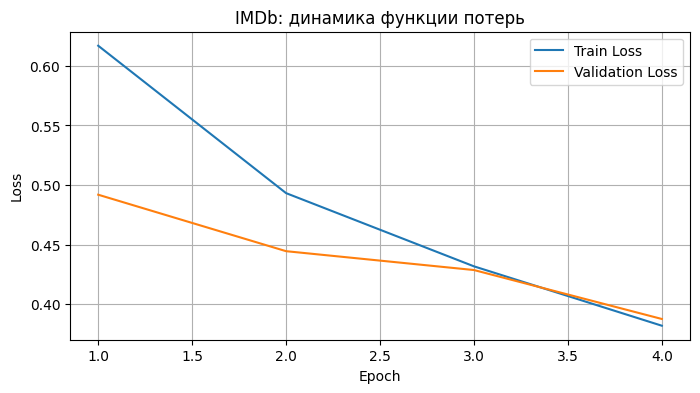

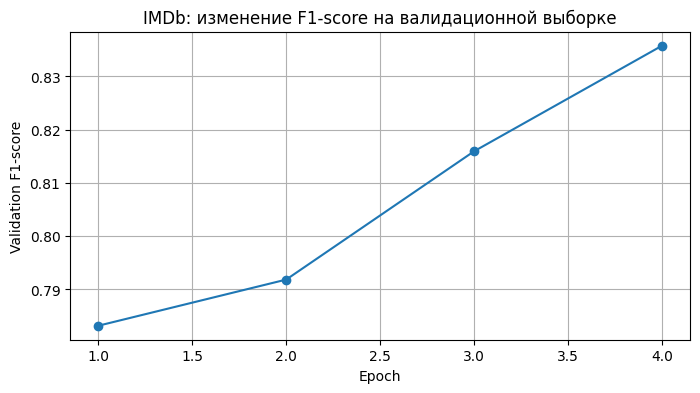

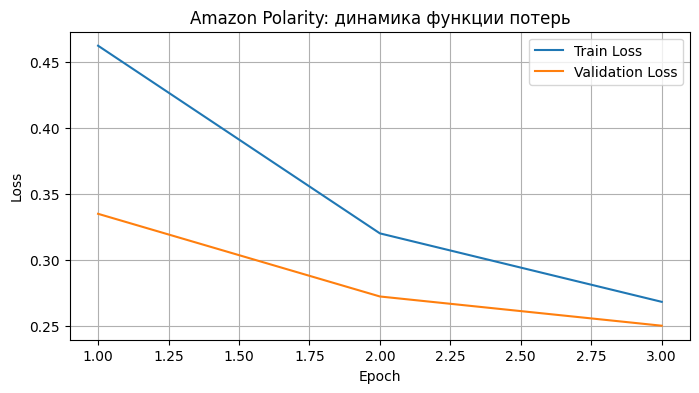

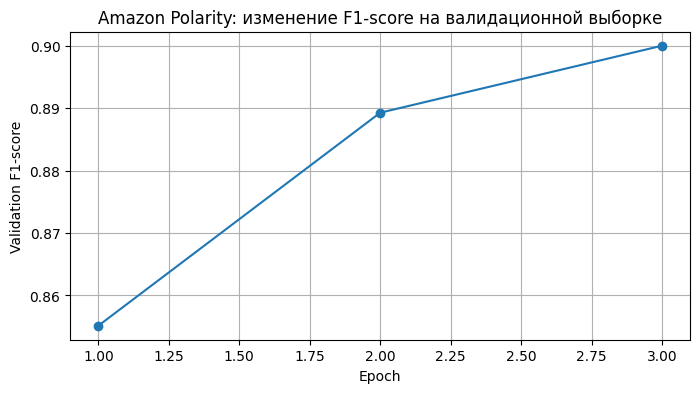

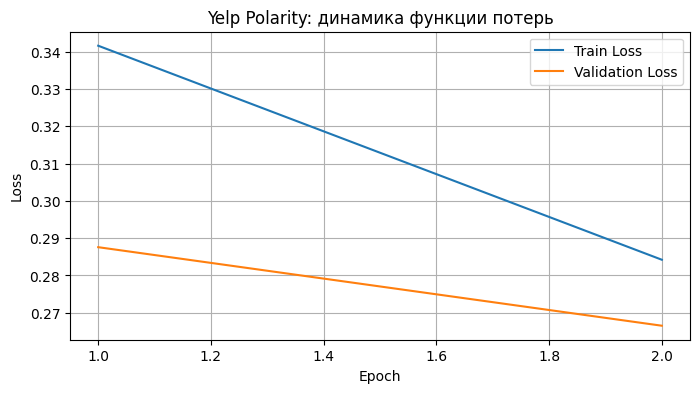

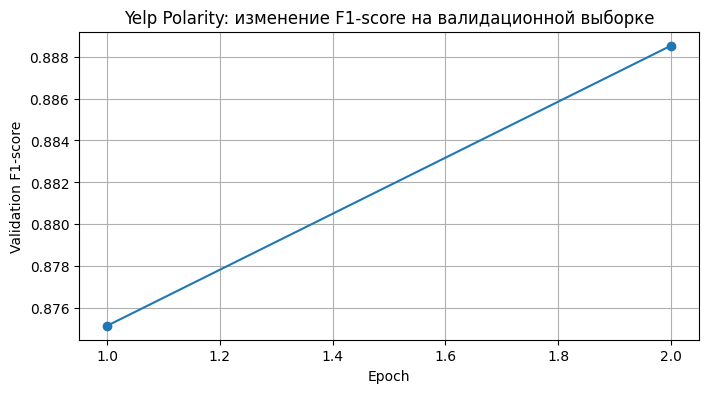

In [ ]:
plot_history(textcnn_artifacts["IMDb"]["history_df"], "IMDb")
plot_history(textcnn_artifacts["Amazon Polarity"]["history_df"], "Amazon Polarity")
plot_history(textcnn_artifacts["Yelp Polarity"]["history_df"], "Yelp Polarity")

### Classification report для TextCNN

In [ ]:
for dataset_name in ["IMDb", "Amazon Polarity", "Yelp Polarity"]:
    print("=" * 80)
    print(dataset_name)
    print(classification_report(
        textcnn_artifacts[dataset_name]["test_true"],
        textcnn_artifacts[dataset_name]["test_preds"],
        digits=4
    ))

IMDb
              precision    recall  f1-score   support

           0     0.8709    0.7649    0.8145     12361
           1     0.7916    0.8874    0.8368     12440

    accuracy                         0.8263     24801
   macro avg     0.8313    0.8261    0.8256     24801
weighted avg     0.8312    0.8263    0.8257     24801

Amazon Polarity
              precision    recall  f1-score   support

           0     0.8979    0.8844    0.8911     10000
           1     0.8861    0.8994    0.8927     10000

    accuracy                         0.8919     20000
   macro avg     0.8920    0.8919    0.8919     20000
weighted avg     0.8920    0.8919    0.8919     20000

Yelp Polarity
              precision    recall  f1-score   support

           0     0.9036    0.8673    0.8851     19000
           1     0.8724    0.9075    0.8896     19000

    accuracy                         0.8874     38000
   macro avg     0.8880    0.8874    0.8873     38000
weighted avg     0.8880    0.8874    0.

### Матрицы ошибок для TextCNN

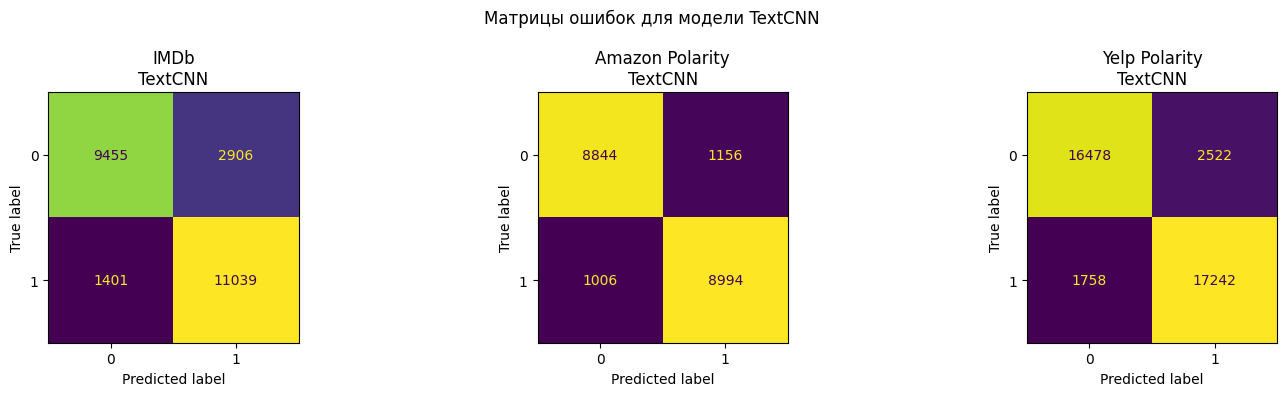

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, dataset_name in zip(axes, ["IMDb", "Amazon Polarity", "Yelp Polarity"]):
    cm = confusion_matrix(
        textcnn_artifacts[dataset_name]["test_true"],
        textcnn_artifacts[dataset_name]["test_preds"]
    )
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, colorbar=False)
    ax.set_title(f"{dataset_name}\nTextCNN")

plt.suptitle("Матрицы ошибок для модели TextCNN")
plt.tight_layout()
plt.show()

### Вывод по результатам TextCNN

Модель TextCNN показала устойчивые результаты на всех трёх датасетах, однако не превзошла лучшие классические решения на признаках TF-IDF. На тестовой выборке значение F1-score для положительного класса составило 0.8368 на IMDb, 0.8927 на Amazon Polarity и 0.8896 на Yelp Polarity. Наилучший результат среди трёх корпусов был получен на датасете Amazon Polarity.

Графики обучения показывают снижение функции потерь и рост качества на валидационной выборке, что свидетельствует о корректной сходимости модели. Матрицы ошибок подтверждают, что модель в целом успешно разделяет два класса, хотя заметная доля ошибок сохраняется.

Следовательно, TextCNN в данной работе выступает как полноценная глубокая архитектура классификации текста, однако по качеству уступает лучшим комбинациям TF-IDF с Logistic Regression и Linear SVM. При этом результаты TextCNN для Yelp Polarity были получены в упрощённой конфигурации обучения, обусловленной ограничениями вычислительных ресурсов, поэтому они, вероятно, отражают не предельные возможности архитектуры, а её ресурсно-доступный вариант в рамках данной работы.

В целом результаты исследования подтверждают, что выбор способа представления текста оказывает существенное влияние на качество классификации отзывов. Сопоставление классических и нейросетевых подходов позволило оценить их сильные и слабые стороны и показать, что в рассматриваемых условиях наиболее эффективными и практичными оказались модели на признаках TF-IDF, тогда как использование TextCNN расширило исследование за счёт сравнения с глубокой архитектурой автоматического извлечения признаков.